# Cetacean MLP — Calibrated LODO (Vector Scaling + PR-Threshold)

Four prediction strategies compared in LODO:

- **argmax** — standard softmax argmax (baseline)
- **temperature** — single scalar T, fit on full val
- **vector scaling** — per-class `w_c * logit_c + b_c`, fit on full val with class weighting
- **pr_thresh** — per-species F1-optimal threshold fit on val via precision-recall curve;
  argmax among species that clear their threshold, fallback to background if none do

### Inter-species confusion definition
A prediction counts as inter-species confusion if the true label is a species and
the predicted label is ANY species in the training vocabulary.
`sp_hallucination_rate` = fraction of species test rows where prediction is a species
absent from the test fold entirely.

**Rule:** the test set is never used for calibration or threshold fitting.

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [2]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all: {len(meta_all):,} rows")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

meta_all: 247,630 rows
X_all:    (247630, 1536)  dtype=float32
datasets (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Label frames

In [5]:
def build_l2(row):
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('odontocete','mysticete','anthropogenic','background'):
        return t2
    t1 = row['label_t1']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    return None

def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l2 = meta_all.copy(); meta_l2['label'] = meta_l2.apply(build_l2, axis=1)
meta_l2 = meta_l2.dropna(subset=['label']).copy()
print(f"\nL2: {len(meta_l2):,} rows"); print(meta_l2['label'].value_counts().to_string())

meta_l4 = meta_all.copy(); meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows"); print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())


L2: 247,630 rows
label
background       179710
anthropogenic     33896
odontocete        33468
mysticete           556

L4: 247,214 rows
label
background                    213606
Orcinus_orca                   21809
Tursiops_truncatus              7250
Delphinus_delphis               1292
Physeter_macrocephalus          1089
Globicephala_melas               721
Balaenoptera_physalus            539
Delphinidae_unknown              508
Grampus_griseus                  239
Stenella_coeruleoalba            144
Balaenoptera_acutorostrata        17

label               Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                                                                                         

## 2. MLP

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)   # raw logits


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3, lr=1e-3, weight_decay=1e-4,
              batch_size=1024, epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 3. Calibrators

### Temperature scaling
`softmax(logits / T)` — single scalar, fit on full val set.  
Does not change argmax but fixes probability magnitudes.

### Vector scaling
`softmax(w * logits + b)` — per-class scale and bias.  
**L4 / L2:** fit on species-positive val rows only (removes background dominance).  
**L1 binary:** fit on full val — species-only filtering degenerates when there
are only 2 classes (one of which IS the species class).

In [7]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / self.log_T.exp()
    def fit(self, logits_val, y_val, lr=0.01, max_iter=200):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        opt = torch.optim.LBFGS([self.log_T], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            F.cross_entropy(self.forward(logits_t), labels_t).backward()
            return F.cross_entropy(self.forward(logits_t), labels_t)
        opt.step(closure)
        return self
    @property
    def T(self): return self.log_T.exp().item()


class VectorScaler(nn.Module):
    """
    Per-class scale + bias: calibrated_logit_c = w_c * logit_c + b_c
    Optimized across ALL validation data using inverse frequency weighting 
    to handle class imbalance without discarding background profiles.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))   # init: identity
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, logits):
        return logits * self.w + self.b

    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        """
        logits_val : (N, C) val logits
        y_val      : (N,) integer labels
        l2         : L2 regularisation pulling w→1, b→0
        """
        # Do NOT filter out background rows. Convert the complete validation set to tensors.
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)

        # Calculate class weights directly from the validation labels to counter imbalance
        counts = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        class_weights_t = torch.tensor(weights, dtype=torch.float32)

        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)

        def closure():
            opt.zero_grad()
            cal_logits = self.forward(logits_t)
            
            # Use class weights here so rare species are balanced against the background class
            nll = F.cross_entropy(cal_logits, labels_t, weight=class_weights_t)
            
            # L2 regularisation: keep w close to 1, b close to 0
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            loss = nll + reg
            loss.backward()
            return loss

        opt.step(closure)
        return self

def calibrate_and_predict(logits, calibrator):
    with torch.no_grad():
        cal = calibrator(torch.tensor(logits, dtype=torch.float32))
        proba = F.softmax(cal, dim=1).numpy()
    return proba.argmax(axis=1), proba

## 4. Metrics

### Corrected inter-species confusion

A prediction is counted as inter-species confusion if:
- true label is a **species** (not background), AND
- predicted label is **any species in the training vocabulary** — including
  species with zero rows in the test fold.

Additionally: `sp_hallucination_rate` = fraction of species test rows where
the model predicted a species that has **zero true positives in this test fold**.
This is the worst deployment error: confidently asserting a species that is
entirely absent from the recording context.

In [8]:
def compute_metrics(y_true, y_pred, labels_present, n_classes):
    all_labels = list(range(n_classes))
    return {
        'test_macro_f1':            float(f1_score(y_true, y_pred, average='macro',
                                                   labels=labels_present, zero_division=0)),
        'test_macro_f1_full_vocab': float(f1_score(y_true, y_pred, average='macro',
                                                   labels=all_labels, zero_division=0)),
        'test_weighted_f1':         float(f1_score(y_true, y_pred, average='weighted',
                                                   labels=labels_present, zero_division=0)),
        'test_accuracy':            float(accuracy_score(y_true, y_pred)),
        'test_balanced_acc':        float(balanced_accuracy_score(y_true, y_pred)),
    }


def compute_species_metrics(y_true, y_pred, class_names, bg_label):
    """
    Metrics on species-only test rows (true label != background).

    Inter-species confusion: predicted ANY species in the training vocab
    but it was the wrong one — including species absent from the test fold.

    Hallucination rate: predicted a species that has ZERO true positives
    in this test fold (model asserts a species that isn't there at all).
    """
    bg_idx     = class_names.index(bg_label) if bg_label in class_names else -1
    # All species indices in the FULL training vocabulary
    all_sp_idx = set(i for i, c in enumerate(class_names) if i != bg_idx)

    sp_mask    = (y_true != bg_idx)
    sp_present = sorted(np.unique(y_true[sp_mask]).tolist())   # test-present only
    sp_absent  = all_sp_idx - set(sp_present)                  # in vocab but not in test

    if sp_mask.sum() == 0:
        return {k: None for k in [
            'sp_macro_f1','sp_recall','sp_precision','sp_balanced_acc',
            'sp_inter_confusion_rate','sp_hallucination_rate','sp_n_rows'
        ]}

    yt = y_true[sp_mask]
    yp = y_pred[sp_mask]
    n  = len(yt)

    # Inter-species confusion: wrong species predicted (vocab-wide)
    inter_conf   = float(((yp != yt) & np.isin(yp, list(all_sp_idx))).sum() / n)

    # Hallucination: predicted a species absent from this test fold
    hallucination = float(np.isin(yp, list(sp_absent)).sum() / n)

    return {
        'sp_macro_f1':             float(f1_score(yt, yp, average='macro',
                                                  labels=sp_present, zero_division=0)),
        'sp_recall':               float(recall_score(yt, yp, average='macro',
                                                      labels=sp_present, zero_division=0)),
        'sp_precision':            float(precision_score(yt, yp, average='macro',
                                                         labels=sp_present, zero_division=0)),
        'sp_balanced_acc':         float(balanced_accuracy_score(yt, yp)),
        'sp_inter_confusion_rate': inter_conf,
        'sp_hallucination_rate':   hallucination,
        'sp_n_rows':               int(n),
    }


def per_class_f1(y_true, y_pred, class_names):
    n   = len(class_names)
    f1s = f1_score(y_true, y_pred, labels=list(range(n)), average=None, zero_division=0)
    return {class_names[i]: float(f1s[i]) for i in range(n)}

## 5. LODO runner

## 3b. PR-threshold calibrator

For each species class, sweep all unique probability values on the val set
and pick the threshold that maximises per-class F1.
At inference, a row is assigned the highest-scoring species that clears its threshold;
if no species qualifies the row falls back to background.

In [9]:
from sklearn.metrics import precision_recall_curve

def fit_pr_thresholds(proba_val, y_val, class_names, bg_idx, min_thr=0.01):
    """
    Fit per-species F1-optimal thresholds on val probabilities.
    Returns dict: class_name -> threshold.
    Background gets threshold 0.0 (always qualifies as fallback).
    """
    thresholds = {}
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            thresholds[cls_name] = 0.0
            continue
        y_bin = (y_val == cls_idx).astype(int)
        if y_bin.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        precs, recs, thrs = precision_recall_curve(y_bin, proba_val[:, cls_idx])
        f1s  = 2 * precs * recs / np.clip(precs + recs, 1e-9, None)
        f1s  = f1s[:-1]   # trailing point has no threshold
        valid = thrs >= min_thr
        if valid.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        best = np.argmax(f1s[valid])
        thresholds[cls_name] = float(thrs[valid][best])
    return thresholds


def predict_with_pr_thresholds(proba, class_names, thresholds, bg_idx):
    """
    For each row: take argmax among classes that exceed their threshold.
    If nothing qualifies, fall back to background.
    """
    qualify = np.zeros(proba.shape, dtype=bool)
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            qualify[:, cls_idx] = True   # bg always qualifies as fallback
            continue
        thr = thresholds.get(cls_name, 0.5)
        qualify[:, cls_idx] = proba[:, cls_idx] >= thr
    masked = np.where(qualify, proba, -np.inf)
    return masked.argmax(axis=1)


In [10]:
def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def run_calibrated_lodo(held_out, meta_df, label_col='label',
                        bg_label='background', species_only_fit=True,
                        min_train_per_class=5, val_size=0.12, verbose=True):
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep

    if verbose:
        print(f"\n  [{held_out}] train classes ({len(train_keep)}): {sorted(train_keep)}")
        print(f"  [{held_out}] test composition:")
        for c, n in test_meta[label_col].value_counts().items():
            mark = 'OK' if c in train_keep else 'NOT in train — dropped'
            print(f"      {c:35s} n={n:>6,}  ({mark})")

    if len(train_keep) < 2: return None
    if len(test_keep)  < 1: return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))
    Xte_s = sc.transform(np.asarray(X_all[rows_te], dtype=np.float32))
    ytr   = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva   = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte   = test_meta['y'].values

    sp_rows_val = int((yva != bg_idx).sum()) if bg_idx >= 0 else len(yva)
    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  "
              f"(sp_val={sp_rows_val:,})  test={len(rows_te):,}")

    t0             = time.time()
    model, best_va = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed        = time.time() - t0

    logits_va = get_logits(model, Xva_s)
    logits_te = get_logits(model, Xte_s)

    # A: argmax
    proba_raw = torch.softmax(torch.tensor(logits_te), dim=1).numpy()
    y_argmax  = proba_raw.argmax(axis=1)

    # B: temperature scaling
    temp_scaler = TemperatureScaler()
    temp_scaler.fit(logits_va, yva)
    y_temp, proba_temp = calibrate_and_predict(logits_te, temp_scaler)

    # C: vector scaling
    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3)
    y_vec, proba_vec = calibrate_and_predict(logits_te, vec_scaler)

    # D: PR-threshold (fit on raw val probs)
    proba_va_raw  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
    pr_thresholds = fit_pr_thresholds(proba_va_raw, yva, class_names, bg_idx)
    y_pr_thresh   = predict_with_pr_thresholds(proba_raw, class_names, pr_thresholds, bg_idx)

    if verbose:
        print(f"  [{held_out}] T={temp_scaler.T:.3f}")
        print(f"  [{held_out}] vector scales:")
        for cn, w, b in zip(class_names,
                            vec_scaler.w.detach().numpy(),
                            vec_scaler.b.detach().numpy()):
            print(f"      {cn:35s}  w={w:+.3f}  b={b:+.3f}")
        print(f"  [{held_out}] PR thresholds:")
        for cn, t in sorted(pr_thresholds.items(), key=lambda kv: kv[1]):
            n_val = int((yva == class_names.index(cn)).sum()) if cn in class_names else 0
            print(f"      {cn:35s}  thr={t:.3f}  n_val={n_val}")

    present = sorted(np.unique(yte).tolist())

    return {
        'held_out':              held_out,
        'class_names':           class_names,
        'n_classes':             n_cls,
        'bg_idx':                bg_idx,
        'n_train':               len(rows_tr),
        'n_val':                 len(rows_va),
        'n_val_species':         sp_rows_val,
        'n_test':                len(rows_te),
        'rows_te':               rows_te,
        'val_macro_f1':          float(best_va),
        'elapsed_s':             float(elapsed),
        'temperature':           float(temp_scaler.T),
        'vec_w':                 vec_scaler.w.detach().numpy().copy(),
        'vec_b':                 vec_scaler.b.detach().numpy().copy(),
        'pr_thresholds':         pr_thresholds,
        'yte':                   yte,
        'y_argmax':              y_argmax,
        'y_temp':                y_temp,
        'y_vec':                 y_vec,
        'y_pr_thresh':           y_pr_thresh,
        'proba_raw':             proba_raw,
        'proba_temp':            proba_temp,
        'proba_vec':             proba_vec,
        'metrics_argmax':        compute_metrics(yte, y_argmax,    present, n_cls),
        'metrics_temp':          compute_metrics(yte, y_temp,      present, n_cls),
        'metrics_vec':           compute_metrics(yte, y_vec,       present, n_cls),
        'metrics_pr_thresh':     compute_metrics(yte, y_pr_thresh, present, n_cls),
        'sp_argmax':             compute_species_metrics(yte, y_argmax,    class_names, bg_label),
        'sp_temp':               compute_species_metrics(yte, y_temp,      class_names, bg_label),
        'sp_vec':                compute_species_metrics(yte, y_vec,       class_names, bg_label),
        'sp_pr_thresh':          compute_species_metrics(yte, y_pr_thresh, class_names, bg_label),
        'pc_f1_argmax':          per_class_f1(yte, y_argmax,    class_names),
        'pc_f1_temp':            per_class_f1(yte, y_temp,      class_names),
        'pc_f1_vec':             per_class_f1(yte, y_vec,       class_names),
        'pc_f1_pr_thresh':       per_class_f1(yte, y_pr_thresh, class_names),
        'test_classes_present':  present,
        'model':                 model,
        'scaler':                sc,
        'temp_scaler':           temp_scaler,
        'vec_scaler':            vec_scaler,
    }


def run_lodo_level(meta_df, label_col, level_name, holdouts,
                   bg_label='background', species_only_fit=True,
                   min_train_per_class=5, val_size=0.12, verbose=True):
    results = {}
    for ds in tqdm(holdouts, desc=f'{level_name} LODO'):
        r = run_calibrated_lodo(
            ds, meta_df, label_col=label_col, bg_label=bg_label,
            species_only_fit=species_only_fit,
            min_train_per_class=min_train_per_class,
            val_size=val_size, verbose=verbose)
        if r is not None:
            results[ds] = r
    return results


## 6. Summary and plotting helpers

In [11]:
def make_summary_df(results, level_name):
    rows = []
    for ds, r in results.items():
        ma = r['metrics_argmax'];    mt = r['metrics_temp']
        mv = r['metrics_vec'];       mp = r['metrics_pr_thresh']
        sa = r['sp_argmax'];         st = r['sp_temp']
        sv = r['sp_vec'];            sp = r['sp_pr_thresh']
        rows.append({
            'level':                level_name,
            'held_out':             ds,
            'n_test':               r['n_test'],
            'n_val_species':        r['n_val_species'],
            'n_classes_test':       len(r['test_classes_present']),
            'temperature':          round(r['temperature'], 3),
            'argmax_macro_f1':      ma['test_macro_f1'],
            'temp_macro_f1':        mt['test_macro_f1'],
            'vec_macro_f1':         mv['test_macro_f1'],
            'pr_thresh_macro_f1':   mp['test_macro_f1'],
            'delta_temp':           mt['test_macro_f1'] - ma['test_macro_f1'],
            'delta_vec':            mv['test_macro_f1'] - ma['test_macro_f1'],
            'delta_pr_thresh':      mp['test_macro_f1'] - ma['test_macro_f1'],
            'argmax_sp_recall':     sa.get('sp_recall'),
            'temp_sp_recall':       st.get('sp_recall'),
            'vec_sp_recall':        sv.get('sp_recall'),
            'pr_thresh_sp_recall':  sp.get('sp_recall'),
            'argmax_sp_prec':       sa.get('sp_precision'),
            'temp_sp_prec':         st.get('sp_precision'),
            'vec_sp_prec':          sv.get('sp_precision'),
            'pr_thresh_sp_prec':    sp.get('sp_precision'),
            'argmax_sp_f1':         sa.get('sp_macro_f1'),
            'temp_sp_f1':           st.get('sp_macro_f1'),
            'vec_sp_f1':            sv.get('sp_macro_f1'),
            'pr_thresh_sp_f1':      sp.get('sp_macro_f1'),
            'argmax_inter_conf':    sa.get('sp_inter_confusion_rate'),
            'vec_inter_conf':       sv.get('sp_inter_confusion_rate'),
            'pr_thresh_inter_conf': sp.get('sp_inter_confusion_rate'),
            'argmax_hallucin':      sa.get('sp_hallucination_rate'),
            'vec_hallucin':         sv.get('sp_hallucination_rate'),
            'pr_thresh_hallucin':   sp.get('sp_hallucination_rate'),
            'sp_n_rows':            sa.get('sp_n_rows', 0),
        })
    return pd.DataFrame(rows).sort_values('pr_thresh_sp_f1', ascending=False, na_position='last')


def per_class_delta_heatmap(results, strategy_key, base_key,
                             title, out_path, bg_label='background'):
    delta_rows = []
    for ds, r in results.items():
        class_names = r['class_names']
        present     = set(r['test_classes_present'])
        f1_base     = r[f'pc_f1_{base_key}']
        f1_strat    = r[f'pc_f1_{strategy_key}']
        for c_idx, c_name in enumerate(class_names):
            if c_idx not in present:
                delta_rows.append({'held_out': ds, 'class': c_name, 'delta': np.nan})
            else:
                delta_rows.append({
                    'held_out': ds, 'class': c_name,
                    'delta':    f1_strat[c_name] - f1_base[c_name],
                })
    df          = pd.DataFrame(delta_rows)
    delta_pivot = df.pivot(index='held_out', columns='class', values='delta')
    sp_cols     = [c for c in delta_pivot.columns if c != bg_label]
    sp_sorted   = delta_pivot[sp_cols].mean(skipna=True).sort_values().index.tolist()
    col_order   = sp_sorted + ([bg_label] if bg_label in delta_pivot.columns else [])
    delta_pivot = delta_pivot[col_order]
    vabs  = max(np.nanmax(np.abs(delta_pivot.values)), 0.01)
    annot = delta_pivot.copy().round(3).astype(str)
    annot[delta_pivot.isna()] = '—'
    fig, ax = plt.subplots(figsize=(max(10, 0.8*len(delta_pivot.columns)+2),
                                    max(5,  0.5*len(delta_pivot)+1.5)))
    sns.heatmap(delta_pivot, cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
                annot=annot, fmt='', linewidths=0.3, ax=ax,
                mask=delta_pivot.isna(),
                cbar_kws={'label': f'ΔF1 ({strategy_key} − {base_key})'})
    ax.set_facecolor('#e8e8e8')
    ax.set_title(title, fontsize=10)
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    ax.set_xlabel('class'); ax.set_ylabel('held-out dataset')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMean ΔF1 per class ({strategy_key} − {base_key}):")
    print(delta_pivot.mean(skipna=True).round(3).sort_values().to_string())
    return df


def report_fold(r, bg_label='background'):
    ds            = r['held_out']
    class_names   = r['class_names']
    present       = r['test_classes_present']
    present_names = [class_names[i] for i in present]
    n_cls         = r['n_classes']

    print(f"\n{'='*82}")
    print(f"  {ds}  |  T={r['temperature']:.3f}  |  classes: {present_names}")
    print(f"{'='*82}")
    print(f"  {'metric':38s}  {'argmax':>8s}  {'temp':>8s}  {'vec':>8s}  {'pr_thr':>8s}")
    print(f"  {'-'*78}")
    for key, label in [
        ('test_macro_f1',     'macro F1 (test classes)'),
        ('test_balanced_acc', 'balanced accuracy'),
    ]:
        a = r['metrics_argmax'][key];    t = r['metrics_temp'][key]
        v = r['metrics_vec'][key];       p = r['metrics_pr_thresh'][key]
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}  {p:>8.3f}")
    print(f"  {'--- species rows only ---':38s}")
    for key, label in [
        ('sp_recall',               'species recall (macro)'),
        ('sp_precision',            'species precision (macro)'),
        ('sp_macro_f1',             'species macro F1'),
        ('sp_inter_confusion_rate', 'inter-species confusion'),
        ('sp_hallucination_rate',   'hallucination rate'),
    ]:
        a = r['sp_argmax'].get(key);     t = r['sp_temp'].get(key)
        v = r['sp_vec'].get(key);        p = r['sp_pr_thresh'].get(key)
        if a is None: continue
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}  {p:>8.3f}")

    if n_cls <= 15:
        fig, axes = plt.subplots(1, 3, figsize=(min(24, 0.6*n_cls*3+3),
                                                max(4, 0.55*len(present)+2)))
        for ax, y_pred, title in [
            (axes[0], r['y_argmax'],    'argmax'),
            (axes[1], r['y_vec'],       'vector scaling'),
            (axes[2], r['y_pr_thresh'], 'PR threshold'),
        ]:
            cm      = confusion_matrix(r['yte'], y_pred, labels=list(range(n_cls)))
            cm_show = cm[present, :]
            cm_norm = cm_show / np.clip(cm_show.sum(axis=1, keepdims=True), 1, None)
            sns.heatmap(cm_norm, annot=cm_show, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=present_names,
                        ax=ax, cbar=False)
            ax.set_title(f'{ds} — {title}', fontsize=9)
            ax.set_xlabel('predicted', fontsize=8)
            ax.set_ylabel('true', fontsize=8)
            plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'cm_{ds}.png', dpi=150, bbox_inches='tight')
        plt.show()


## 8. Level 2 — coarse group

4 classes: odontocete / mysticete / anthropogenic / background.
Vector scaling uses species-positive val rows only.

In [12]:
L2_HOLDOUTS = sorted(meta_l2['dataset'].unique().tolist())
results_l2 = run_lodo_level(
    meta_l2, 'label', 'L2-coarse', L2_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

L2-coarse LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] train classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [ALNITAK_CAVANILLES] test composition:
      background                          n= 4,348  (OK)
      odontocete                          n=   854  (OK)
  [ALNITAK_CAVANILLES] train=211,477  val=30,951  (sp_val=7,085)  test=5,202
  [ALNITAK_CAVANILLES] T=1.202
  [ALNITAK_CAVANILLES] vector scales:
      anthropogenic                        w=+0.984  b=+0.131
      background                           w=+0.849  b=-0.073
      mysticete                            w=+0.434  b=-0.109
      odontocete                           w=+0.851  b=+0.052
  [ALNITAK_CAVANILLES] PR thresholds:
      background                           thr=0.000  n_val=23866
      odontocete                           thr=0.766  n_val=4087
      anthropogenic                        thr=0.988  n_val=2937
      mysticete                            thr=1.000  n_val=61

  [Adriatic_Sea] train classes (4): ['anthropogenic


  ALNITAK_CAVANILLES  |  T=1.202  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.513     0.513     0.515     0.500
  balanced accuracy                          0.520     0.520     0.520     0.516
  --- species rows only ---             
  species recall (macro)                     0.083     0.083     0.091     0.056
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.154     0.154     0.167     0.106
  inter-species confusion                    0.013     0.013     0.008     0.008
  hallucination rate                         0.013     0.013     0.008     0.008


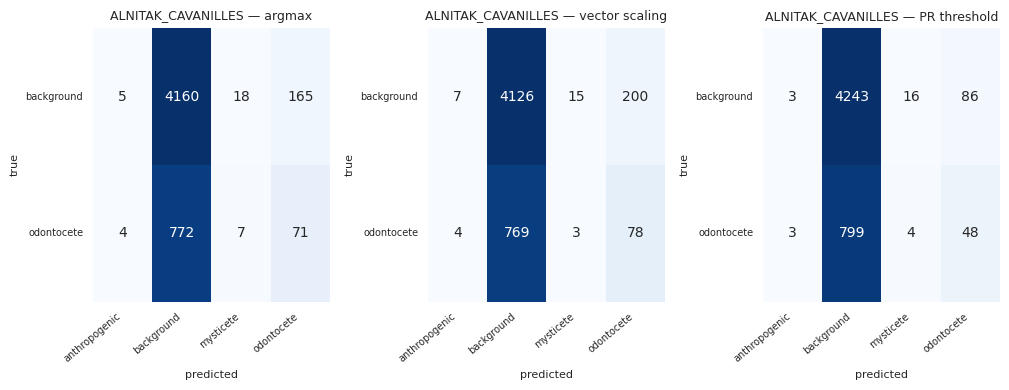


  Adriatic_Sea  |  T=1.097  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.675     0.675     0.691     0.515
  balanced accuracy                          0.806     0.806     0.817     0.695
  --- species rows only ---             
  species recall (macro)                     0.641     0.641     0.663     0.407
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.781     0.781     0.798     0.578
  inter-species confusion                    0.000     0.000     0.001     0.000
  hallucination rate                         0.000     0.000     0.001     0.000


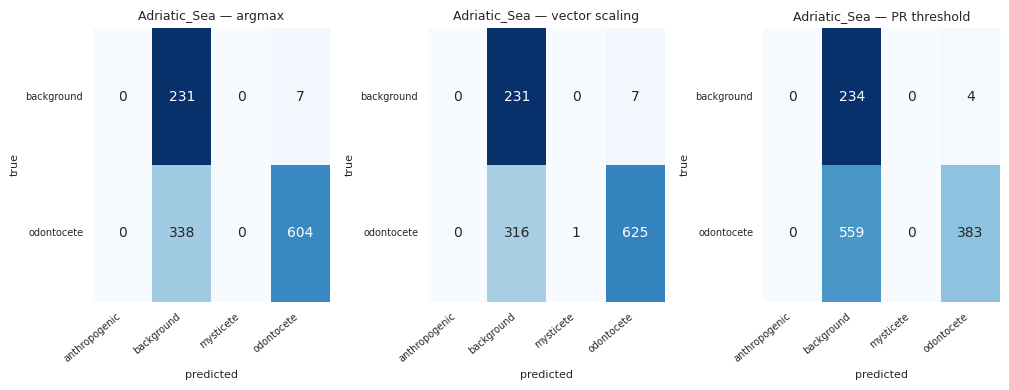


  DCLDE_2026  |  T=0.768  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.572     0.572     0.604     0.625
  balanced accuracy                          0.604     0.604     0.646     0.647
  --- species rows only ---             
  species recall (macro)                     0.505     0.505     0.551     0.470
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.671     0.671     0.711     0.639
  inter-species confusion                    0.011     0.011     0.007     0.002
  hallucination rate                         0.011     0.011     0.007     0.002


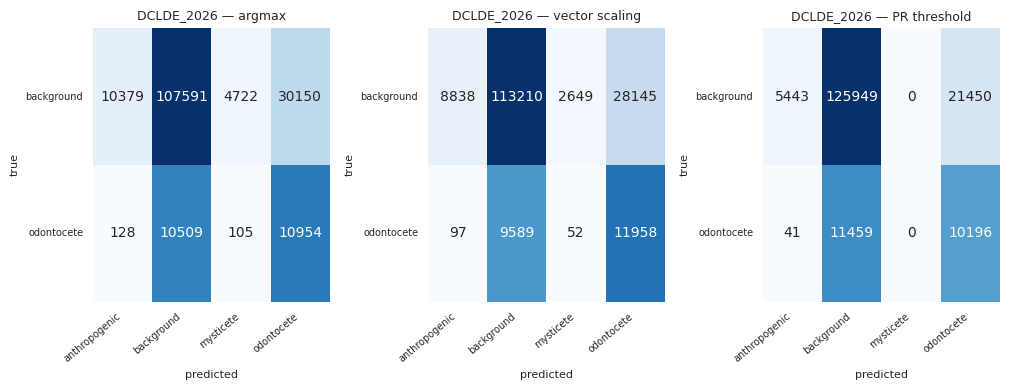


  DOLPHINFREE  |  T=1.321  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.628     0.628     0.570     0.761
  balanced accuracy                          0.692     0.692     0.661     0.784
  --- species rows only ---             
  species recall (macro)                     0.950     0.950     0.964     0.897
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.974     0.974     0.982     0.945
  inter-species confusion                    0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000


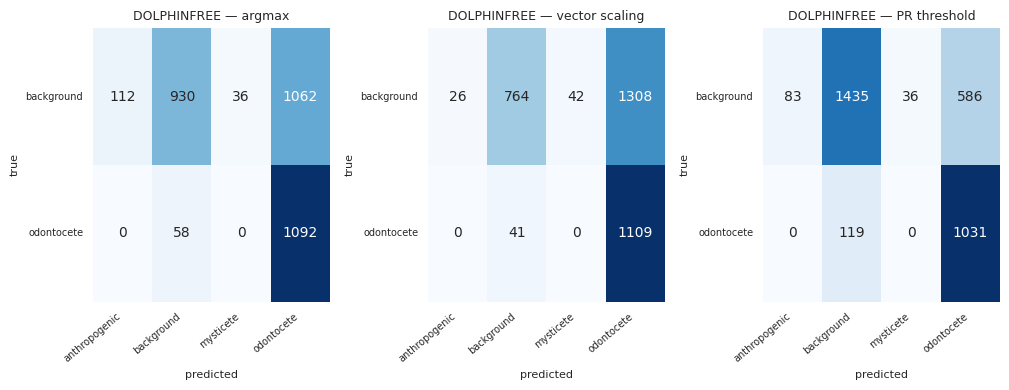


  DRYAD  |  T=1.081  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.683     0.683     0.671     0.759
  balanced accuracy                          0.699     0.699     0.690     0.755
  --- species rows only ---             
  species recall (macro)                     0.874     0.874     0.878     0.804
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.933     0.933     0.935     0.891
  inter-species confusion                    0.053     0.053     0.057     0.056
  hallucination rate                         0.053     0.053     0.057     0.056


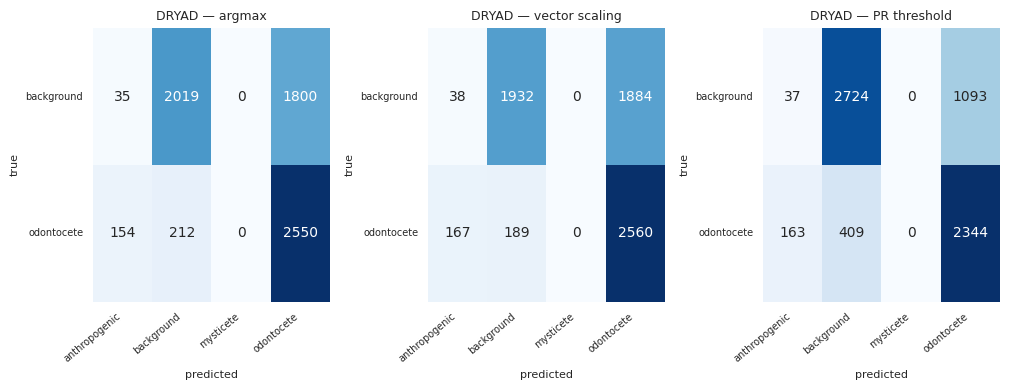


  ECOSS_annot  |  T=1.065  |  classes: ['anthropogenic', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.210     0.210     0.211     0.202
  balanced accuracy                          0.180     0.180     0.182     0.134
  --- species rows only ---             
  species recall (macro)                     0.180     0.180     0.182     0.134
  species precision (macro)                  0.251     0.251     0.250     0.406
  species macro F1                           0.210     0.210     0.211     0.202
  inter-species confusion                    0.227     0.227     0.237     0.039
  hallucination rate                         0.000     0.000     0.005     0.000


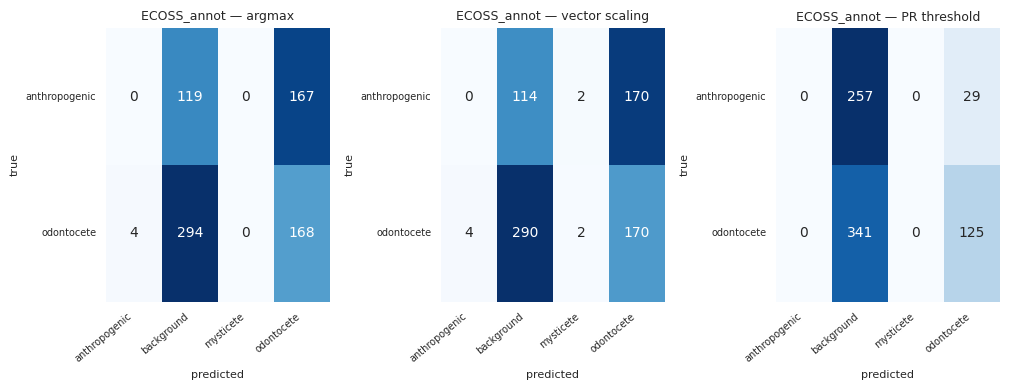


  ECOSS_enhanced  |  T=1.241  |  classes: ['anthropogenic', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.634     0.634     0.636     0.634
  balanced accuracy                          0.573     0.573     0.577     0.573
  --- species rows only ---             
  species recall (macro)                     0.573     0.573     0.577     0.573
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.634     0.634     0.636     0.634
  inter-species confusion                    0.125     0.125     0.125     0.125
  hallucination rate                         0.125     0.125     0.125     0.125


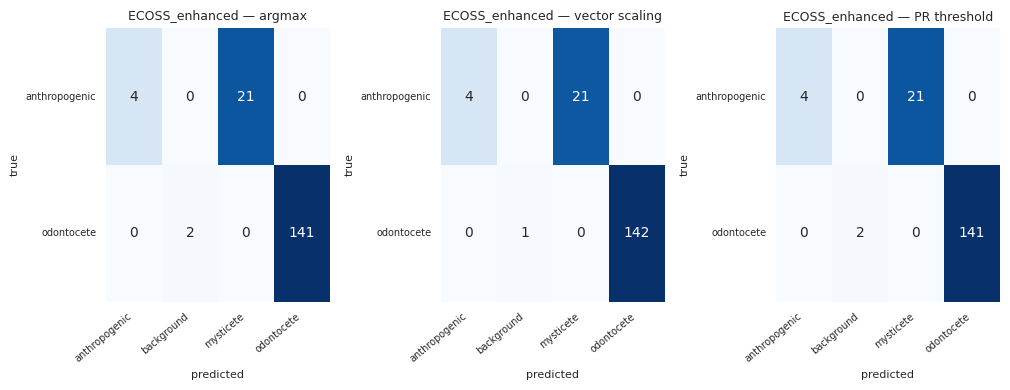


  ECOSS_testtrain  |  T=1.223  |  classes: ['anthropogenic', 'background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.057     0.057     0.058     0.058
  balanced accuracy                          0.615     0.615     0.611     0.607
  --- species rows only ---             
  species recall (macro)                     0.469     0.469     0.473     0.441
  species precision (macro)                  0.507     0.507     0.491     0.510
  species macro F1                           0.014     0.014     0.012     0.021
  inter-species confusion                    0.255     0.255     0.304     0.155
  hallucination rate                         0.000     0.000     0.000     0.000


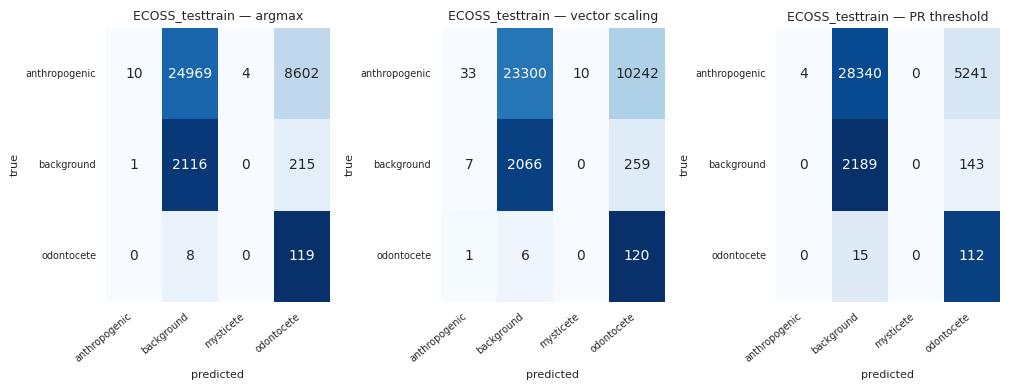


  FREMANTLE  |  T=1.232  |  classes: ['odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.988     0.988     0.985     0.943
  balanced accuracy                          0.976     0.976     0.970     0.892
  --- species rows only ---             
  species recall (macro)                     0.976     0.976     0.970     0.892
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.988     0.988     0.985     0.943
  inter-species confusion                    0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000


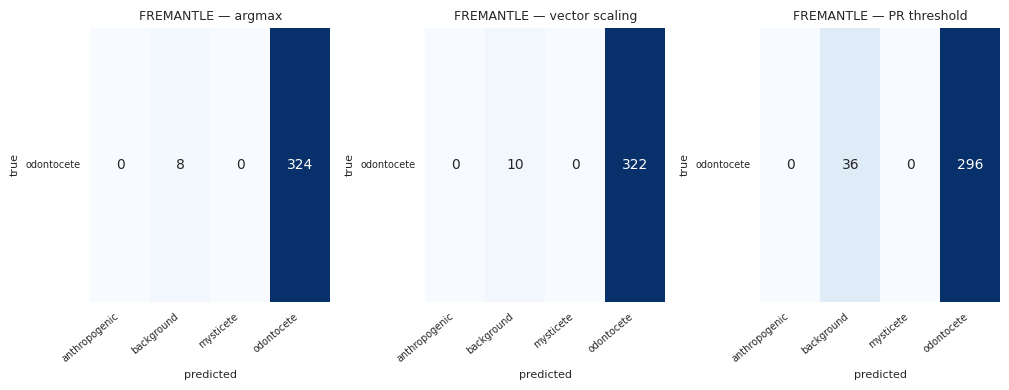


  MONISH  |  T=1.084  |  classes: ['mysticete', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.449     0.449     0.451     0.423
  balanced accuracy                          0.414     0.414     0.418     0.369
  --- species rows only ---             
  species recall (macro)                     0.414     0.414     0.418     0.369
  species precision (macro)                  0.491     0.491     0.491     0.495
  species macro F1                           0.449     0.449     0.451     0.423
  inter-species confusion                    0.130     0.130     0.130     0.071
  hallucination rate                         0.115     0.115     0.115     0.065


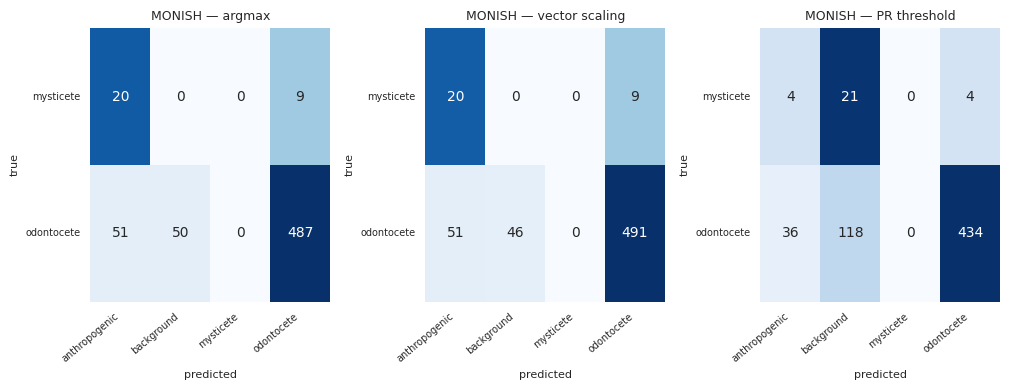


  OLTREMARE  |  T=1.093  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.822     0.822     0.812     0.821
  balanced accuracy                          0.801     0.801     0.813     0.792
  --- species rows only ---             
  species recall (macro)                     0.644     0.644     0.691     0.615
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.784     0.784     0.818     0.762
  inter-species confusion                    0.002     0.002     0.001     0.000
  hallucination rate                         0.002     0.002     0.001     0.000


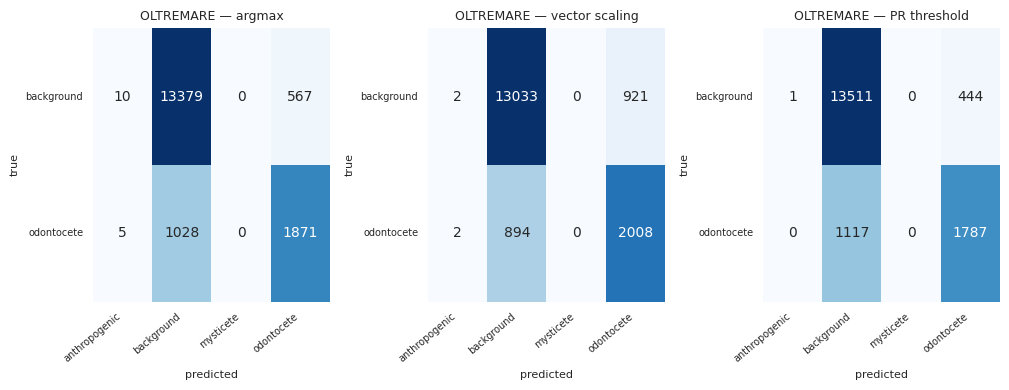


  WATKINS  |  T=1.216  |  classes: ['mysticete', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.460     0.460     0.472     0.445
  balanced accuracy                          0.426     0.426     0.448     0.401
  --- species rows only ---             
  species recall (macro)                     0.426     0.426     0.448     0.401
  species precision (macro)                  0.499     0.499     0.498     0.499
  species macro F1                           0.460     0.460     0.472     0.445
  inter-species confusion                    0.133     0.133     0.174     0.126
  hallucination rate                         0.129     0.129     0.169     0.125


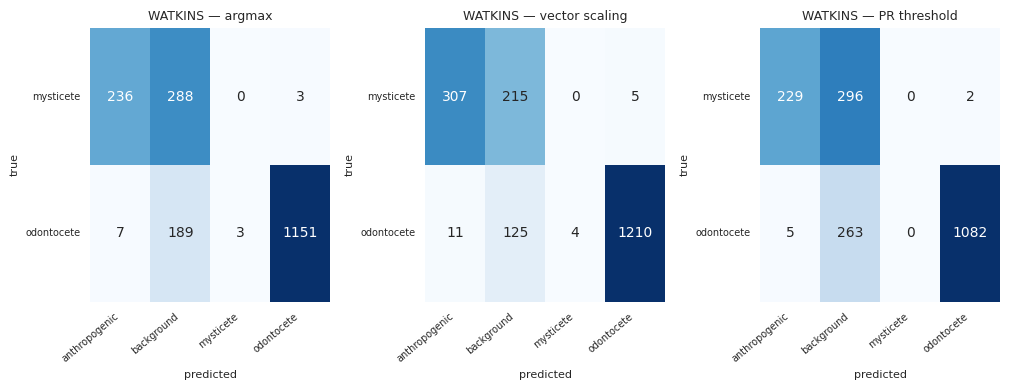

In [13]:
for ds, r in results_l2.items():
    report_fold(r, bg_label='background')

In [14]:
summary_l2 = make_summary_df(results_l2, 'L2-coarse')
print(summary_l2[[
    'held_out','n_test','n_classes_test',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin',
]].to_string(index=False))
summary_l2.to_csv(OUT_DIR / 'summary_l2.csv', index=False)


          held_out  n_test  n_classes_test  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin
       DOLPHINFREE    3290               2          0.949565       0.964348             0.896522        1.000000     1.000000           1.000000      0.974130   0.981850         0.945438         0.000000      0.000000            0.000000
         FREMANTLE     332               1          0.975904       0.969880             0.891566        1.000000     1.000000           1.000000      0.987805   0.984709         0.942675         0.000000      0.000000            0.000000
             DRYAD    6770               2          0.874486       0.877915             0.803841        1.000000     1.000000           1.000000      0.933041   0.934989         0.891255         0.052812      0.057270            0.055898
         OLTREMARE   16860               2      

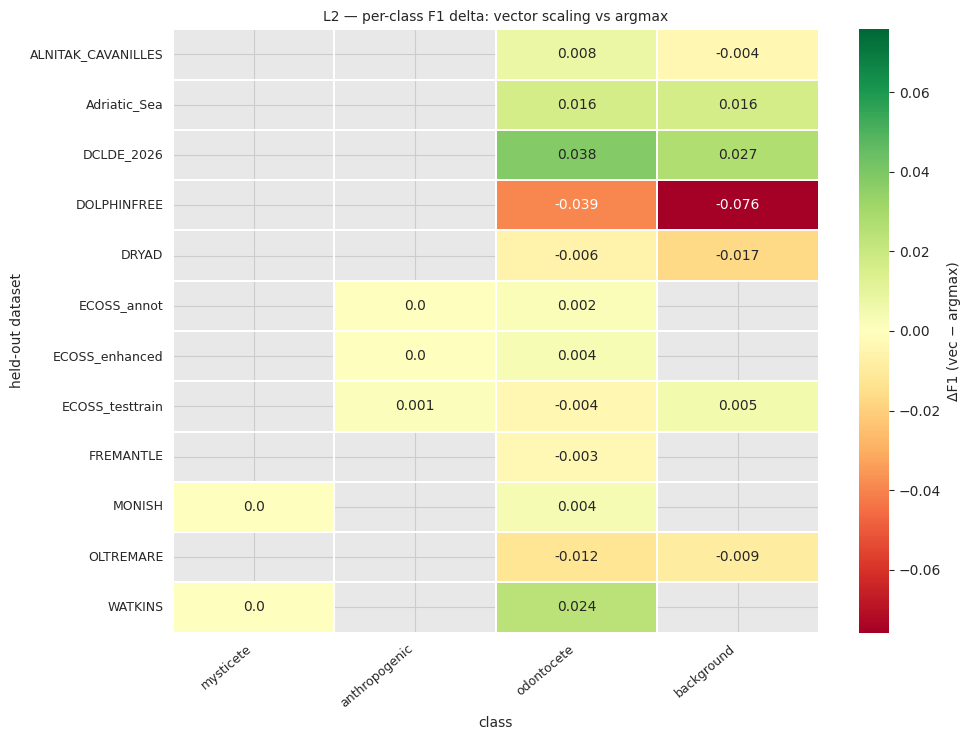


Mean ΔF1 per class (vec − argmax):
class
background      -0.008
mysticete        0.000
anthropogenic    0.000
odontocete       0.003


In [15]:
_ = per_class_delta_heatmap(
    results_l2, 'vec', 'argmax',
    title='L2 — per-class F1 delta: vector scaling vs argmax',
    out_path=OUT_DIR / 'l2_vec_delta_heatmap.png',
    bg_label='background'
)

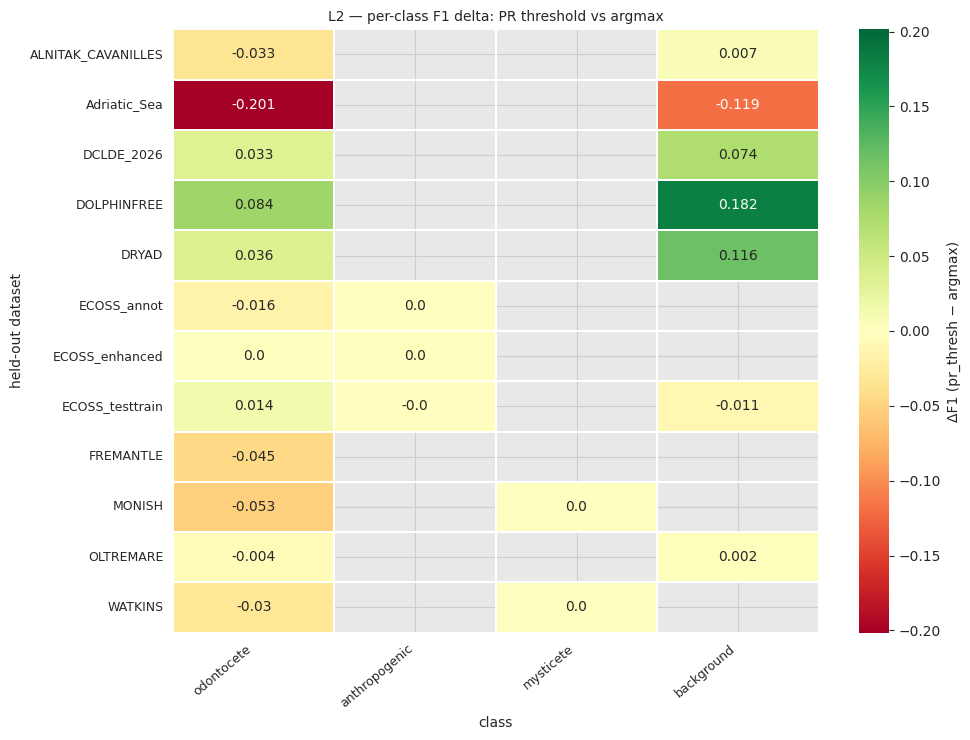


Mean ΔF1 per class (pr_thresh − argmax):
class
odontocete      -0.018
anthropogenic   -0.000
mysticete        0.000
background       0.036


In [16]:
_ = per_class_delta_heatmap(
    results_l2, 'pr_thresh', 'argmax',
    title='L2 — per-class F1 delta: PR threshold vs argmax',
    out_path=OUT_DIR / 'l2_pr_thresh_delta_heatmap.png',
    bg_label='background'
)


## 9. Level 4 — species LODO

86% background, 10 species. Vector scaling calibrated on species-positive
val rows only. The `w` heatmap shows how much each species was sharpened
(`w > 1`) or flattened (`w < 1`) — background should consistently show `w < 1`
and rare species should show `w > 1` if the calibration is working correctly.

In [17]:
L4_HOLDOUTS = sorted(meta_l4['dataset'].unique().tolist())
print(f"{len(L4_HOLDOUTS)} holdouts: {L4_HOLDOUTS}")
results_l4 = run_lodo_level(
    meta_l4, 'label', 'L4-species', L4_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

12 holdouts: ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


L4-species LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] train classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [ALNITAK_CAVANILLES] test composition:
      background                          n= 4,348  (OK)
      Physeter_macrocephalus              n=   179  (OK)
      Globicephala_melas                  n=   141  (OK)
      Tursiops_truncatus                  n=    58  (OK)
      Grampus_griseus                     n=    45  (OK)
      Stenella_coeruleoalba               n=    15  (OK)
  [ALNITAK_CAVANILLES] train=211,477  val=30,951  (sp_val=4,148)  test=4,786
  [ALNITAK_CAVANILLES] T=1.450
  [ALNITAK_CAVANILLES] vector scales:
      Balaenoptera_acutorostrata           w=+0.795  b=-0.176
      Balaenoptera_physalus                w=+0.978  b=-0.020
      Delphinidae_unknown                  w=+0.922  b=-0.1


  ALNITAK_CAVANILLES  |  T=1.450  |  classes: ['Globicephala_melas', 'Grampus_griseus', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.180     0.180     0.182     0.167
  balanced accuracy                          0.175     0.175     0.177     0.171
  --- species rows only ---             
  species recall (macro)                     0.016     0.016     0.019     0.006
  species precision (macro)                  0.418     0.418     0.214     0.267
  species macro F1                           0.030     0.030     0.033     0.011
  inter-species confusion                    0.110     0.110     0.105     0.014
  hallucination rate                         0.062     0.062     0.064     0.009


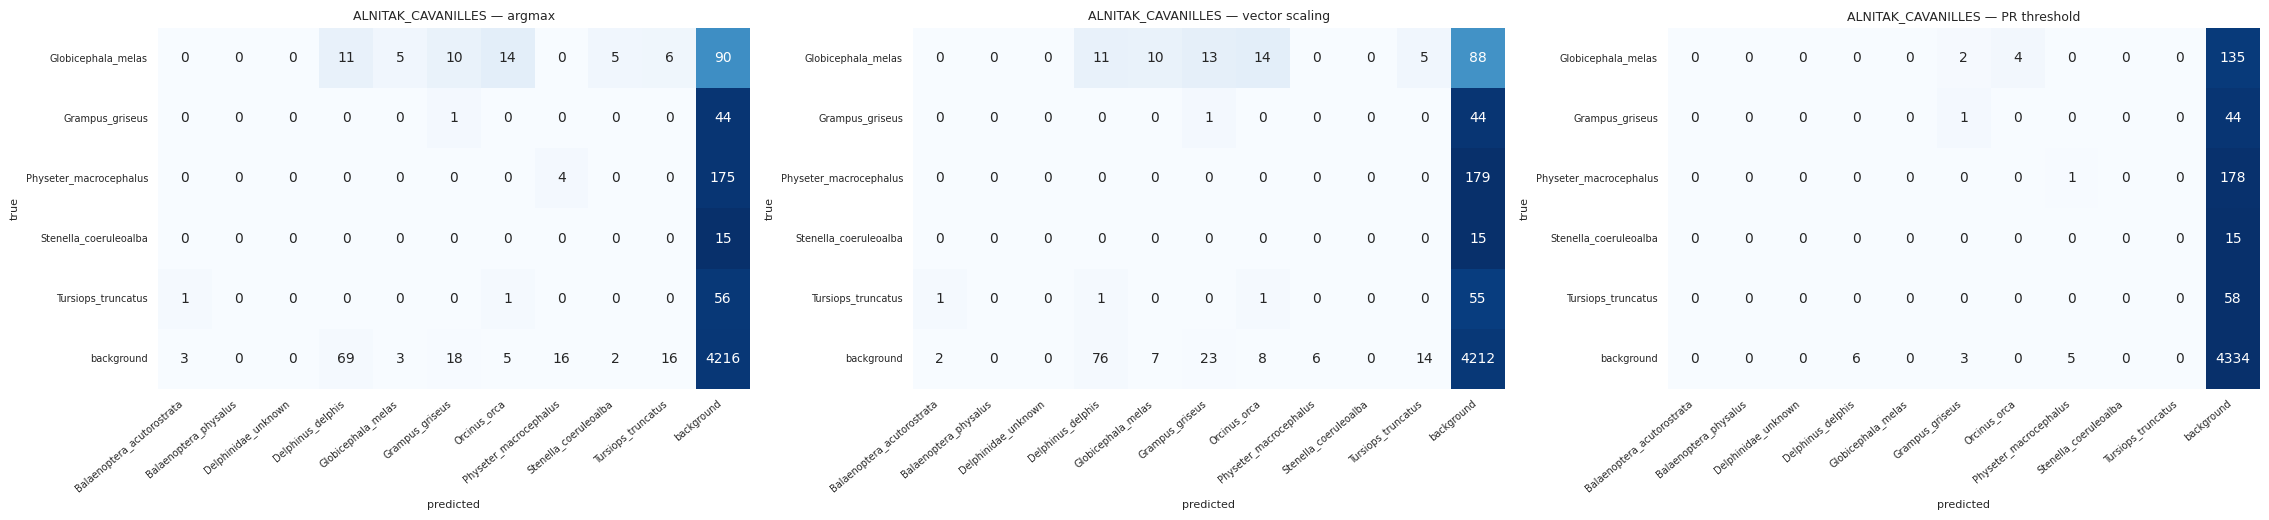


  Adriatic_Sea  |  T=1.434  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.752     0.752     0.704     0.551
  balanced accuracy                          0.800     0.800     0.686     0.716
  --- species rows only ---             
  species recall (macro)                     0.764     0.764     0.738     0.448
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.866     0.866     0.849     0.619
  inter-species confusion                    0.055     0.055     0.139     0.028
  hallucination rate                         0.055     0.055     0.139     0.028


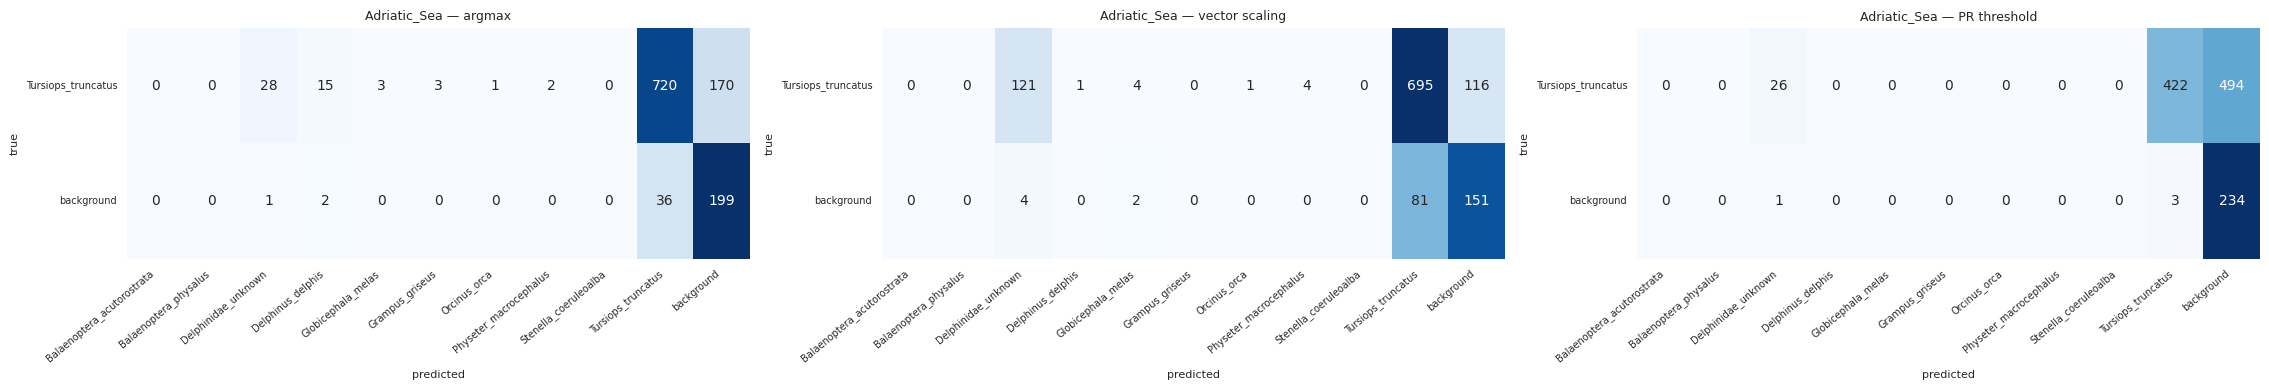


  DCLDE_2026  |  T=1.798  |  classes: ['Orcinus_orca', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.479     0.479     0.445     0.531
  balanced accuracy                          0.383     0.383     0.348     0.462
  --- species rows only ---             
  species recall (macro)                     0.141     0.141     0.283     0.146
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.247     0.247     0.441     0.254
  inter-species confusion                    0.504     0.504     0.565     0.446
  hallucination rate                         0.504     0.504     0.565     0.446


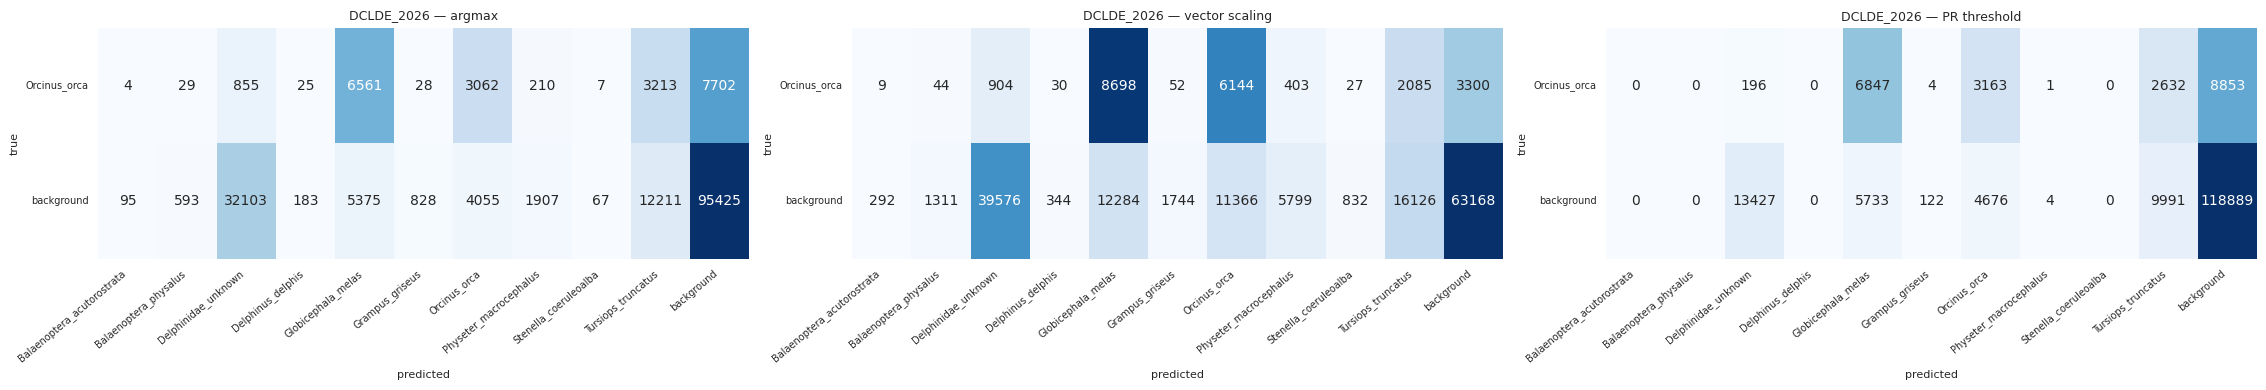


  DOLPHINFREE  |  T=1.449  |  classes: ['Delphinus_delphis', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.339     0.339     0.429     0.399
  balanced accuracy                          0.248     0.248     0.285     0.489
  --- species rows only ---             
  species recall (macro)                     0.032     0.032     0.274     0.000
  species precision (macro)                  1.000     1.000     1.000     0.000
  species macro F1                           0.062     0.062     0.430     0.000
  inter-species confusion                    0.884     0.884     0.681     0.125
  hallucination rate                         0.884     0.884     0.681     0.125


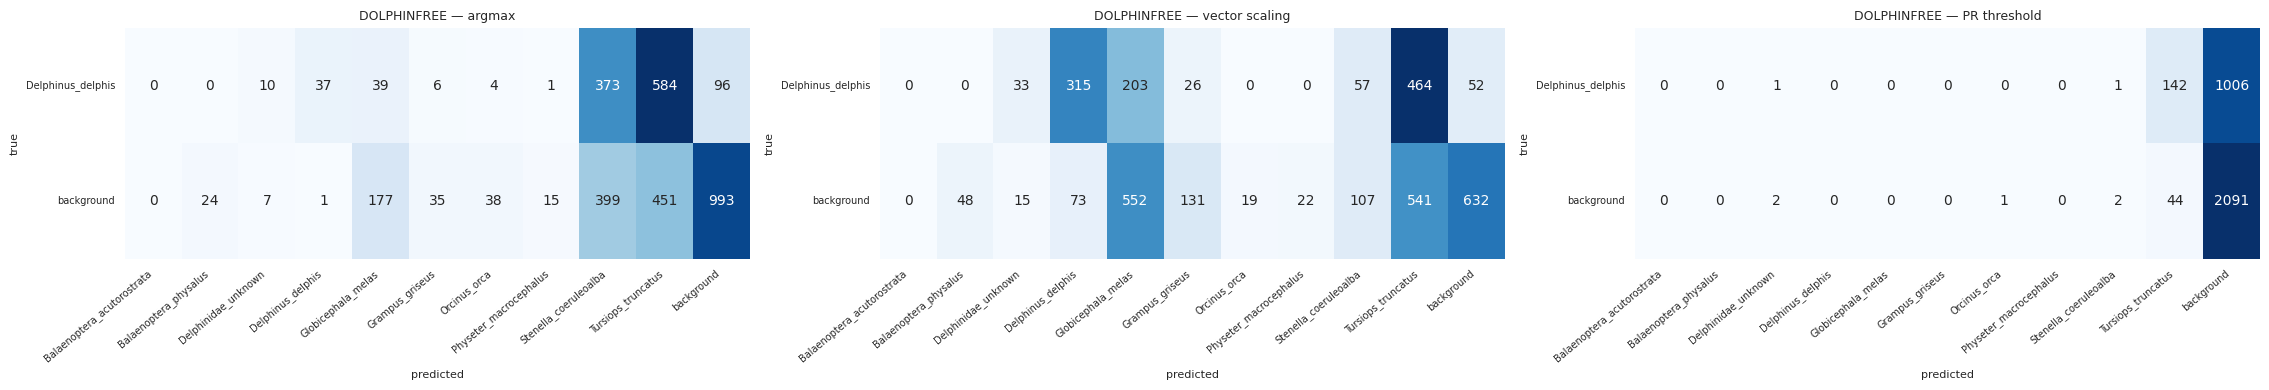


  DRYAD  |  T=1.534  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.643     0.643     0.600     0.627
  balanced accuracy                          0.575     0.575     0.522     0.623
  --- species rows only ---             
  species recall (macro)                     0.621     0.621     0.597     0.330
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.766     0.766     0.748     0.497
  inter-species confusion                    0.267     0.267     0.337     0.037
  hallucination rate                         0.267     0.267     0.337     0.037


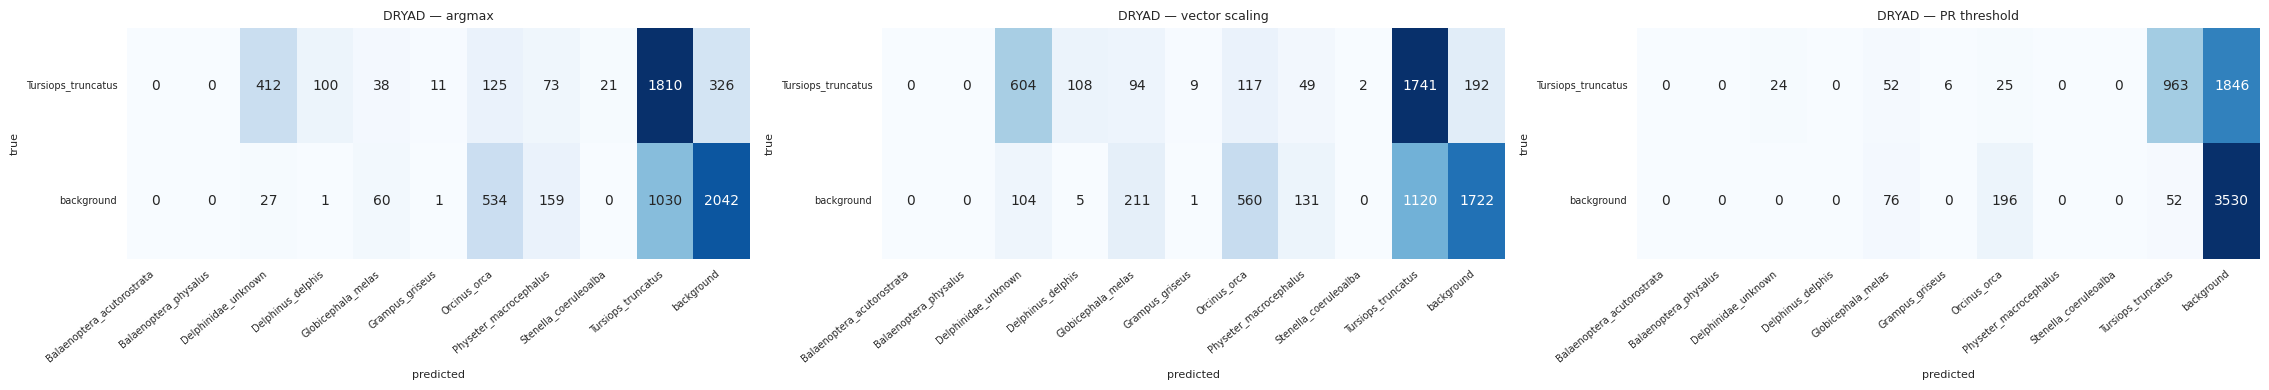


  ECOSS_annot  |  T=1.376  |  classes: ['Delphinidae_unknown', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.300     0.300     0.306     0.282
  balanced accuracy                          0.330     0.330     0.337     0.467
  --- species rows only ---             
  species recall (macro)                     0.000     0.000     0.002     0.000
  species precision (macro)                  0.000     0.000     1.000     0.000
  species macro F1                           0.000     0.000     0.004     0.000
  inter-species confusion                    0.665     0.665     0.670     0.155
  hallucination rate                         0.665     0.665     0.670     0.155


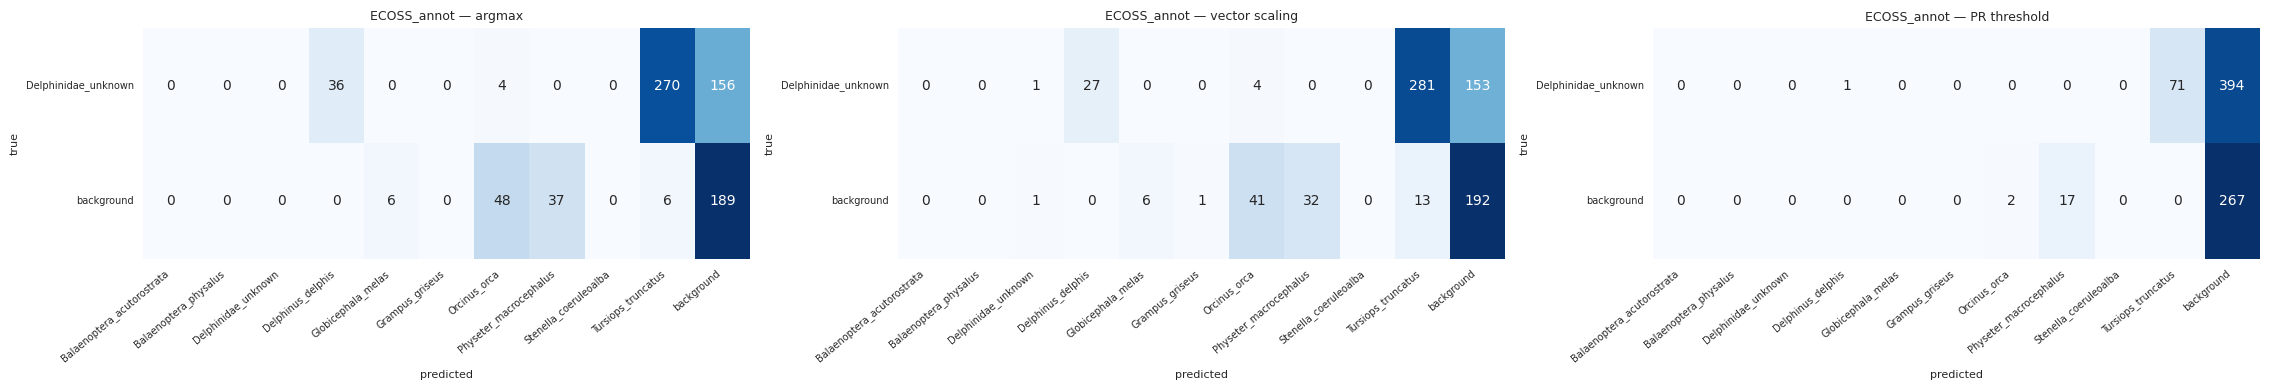


  ECOSS_enhanced  |  T=1.446  |  classes: ['Delphinidae_unknown', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.518     0.518     0.494     0.531
  balanced accuracy                          0.498     0.498     0.474     0.515
  --- species rows only ---             
  species recall (macro)                     0.566     0.566     0.553     0.530
  species precision (macro)                  0.572     0.572     0.580     0.600
  species macro F1                           0.569     0.569     0.564     0.563
  inter-species confusion                    0.615     0.615     0.622     0.490
  hallucination rate                         0.587     0.587     0.601     0.490


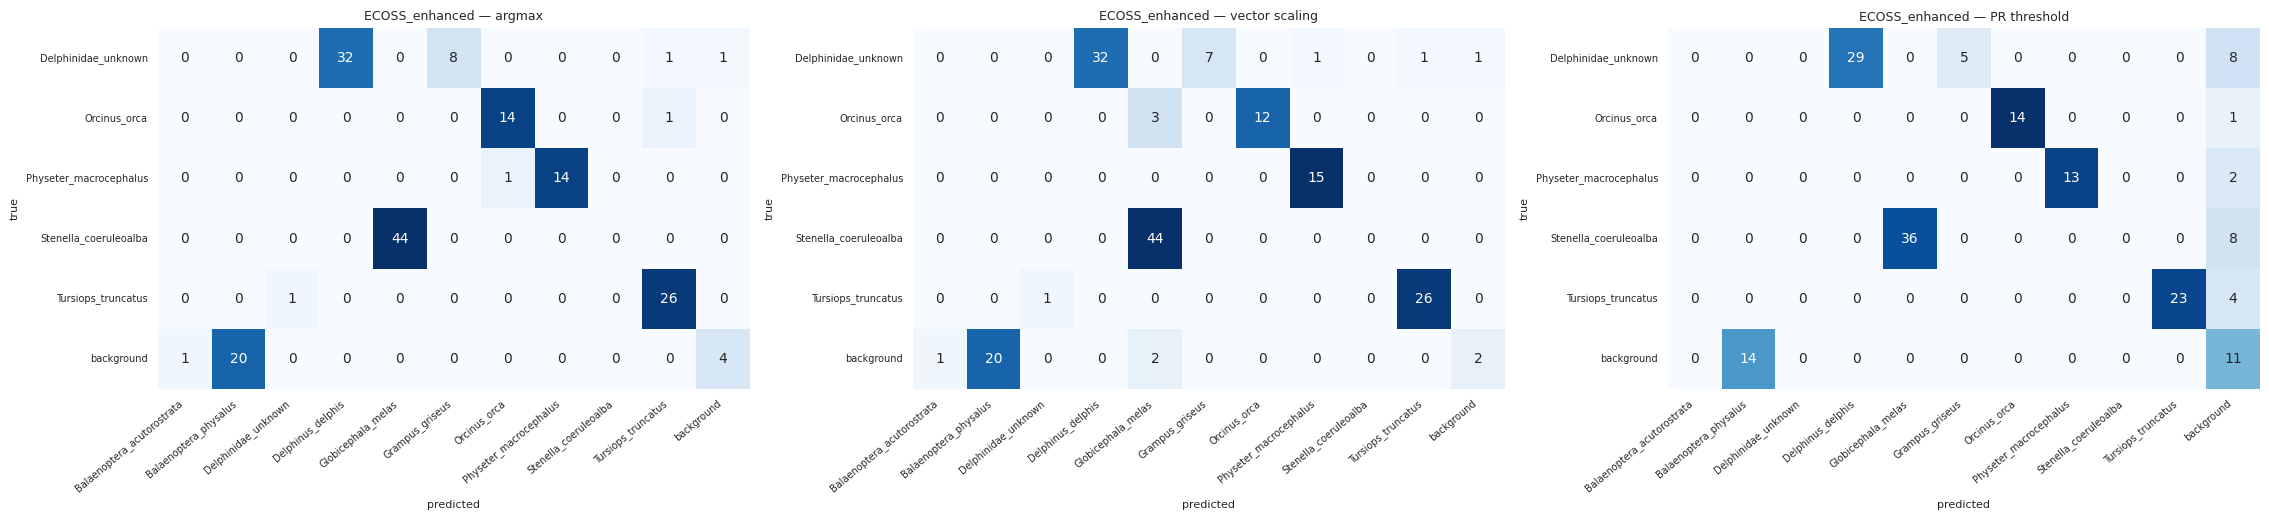


  ECOSS_testtrain  |  T=1.484  |  classes: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.220     0.220     0.221     0.419
  balanced accuracy                          0.617     0.617     0.626     0.483
  --- species rows only ---             
  species recall (macro)                     0.557     0.557     0.582     0.382
  species precision (macro)                  0.639     0.639     0.655     0.744
  species macro F1                           0.513     0.513     0.553     0.443
  inter-species confusion                    0.512     0.512     0.488     0.331
  hallucination rate                         0.315     0.315     0.323     0.291


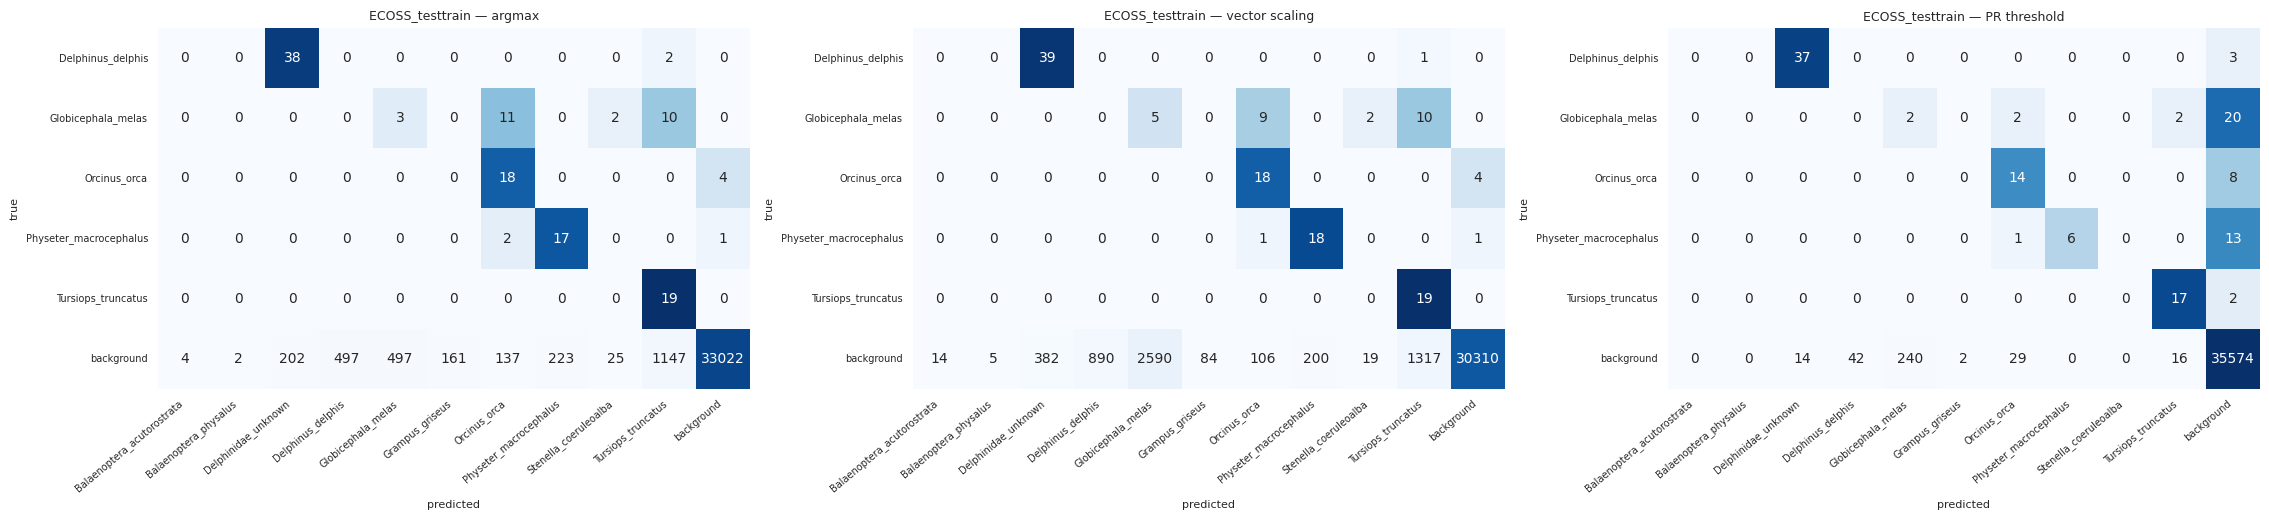


  FREMANTLE  |  T=1.420  |  classes: ['Tursiops_truncatus']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.631     0.631     0.581     0.262
  balanced accuracy                          0.461     0.461     0.410     0.151
  --- species rows only ---             
  species recall (macro)                     0.461     0.461     0.410     0.151
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.631     0.631     0.581     0.262
  inter-species confusion                    0.392     0.392     0.515     0.012
  hallucination rate                         0.392     0.392     0.515     0.012


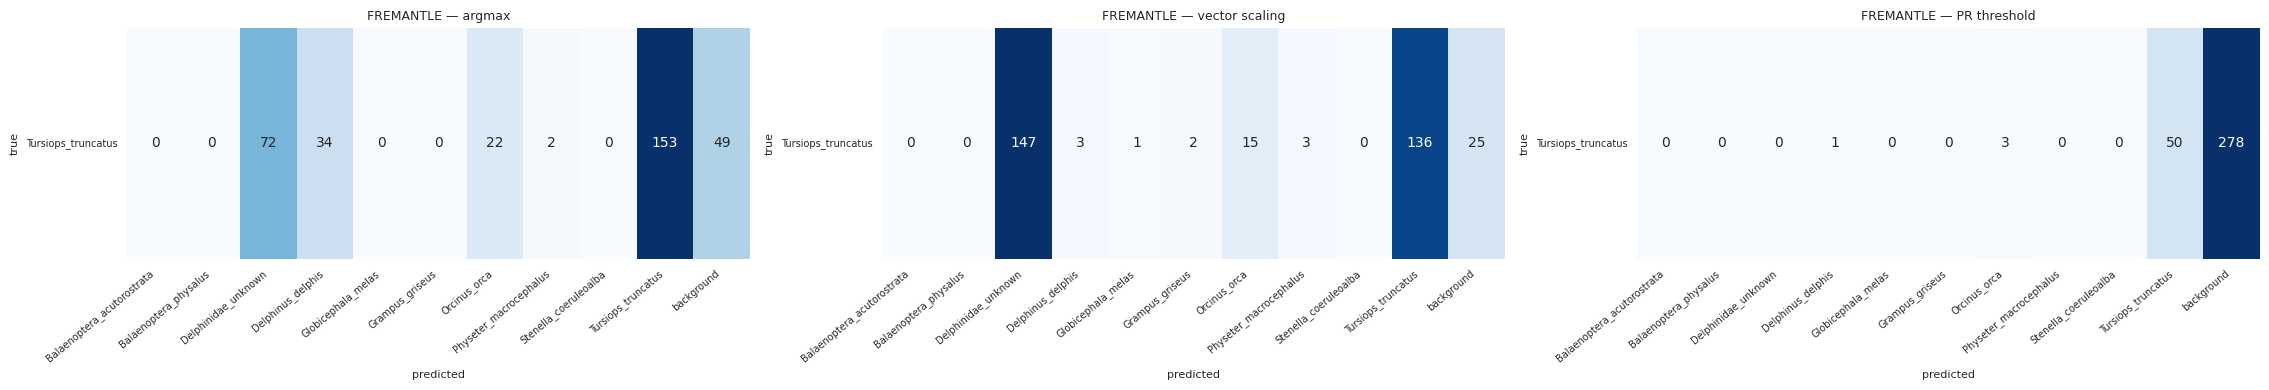


  MONISH  |  T=1.874  |  classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.063     0.063     0.110     0.055
  balanced accuracy                          0.143     0.143     0.183     0.095
  --- species rows only ---             
  species recall (macro)                     0.143     0.143     0.183     0.095
  species precision (macro)                  0.167     0.167     0.117     0.210
  species macro F1                           0.063     0.063     0.110     0.055
  inter-species confusion                    0.815     0.815     0.835     0.514
  hallucination rate                         0.130     0.130     0.160     0.086


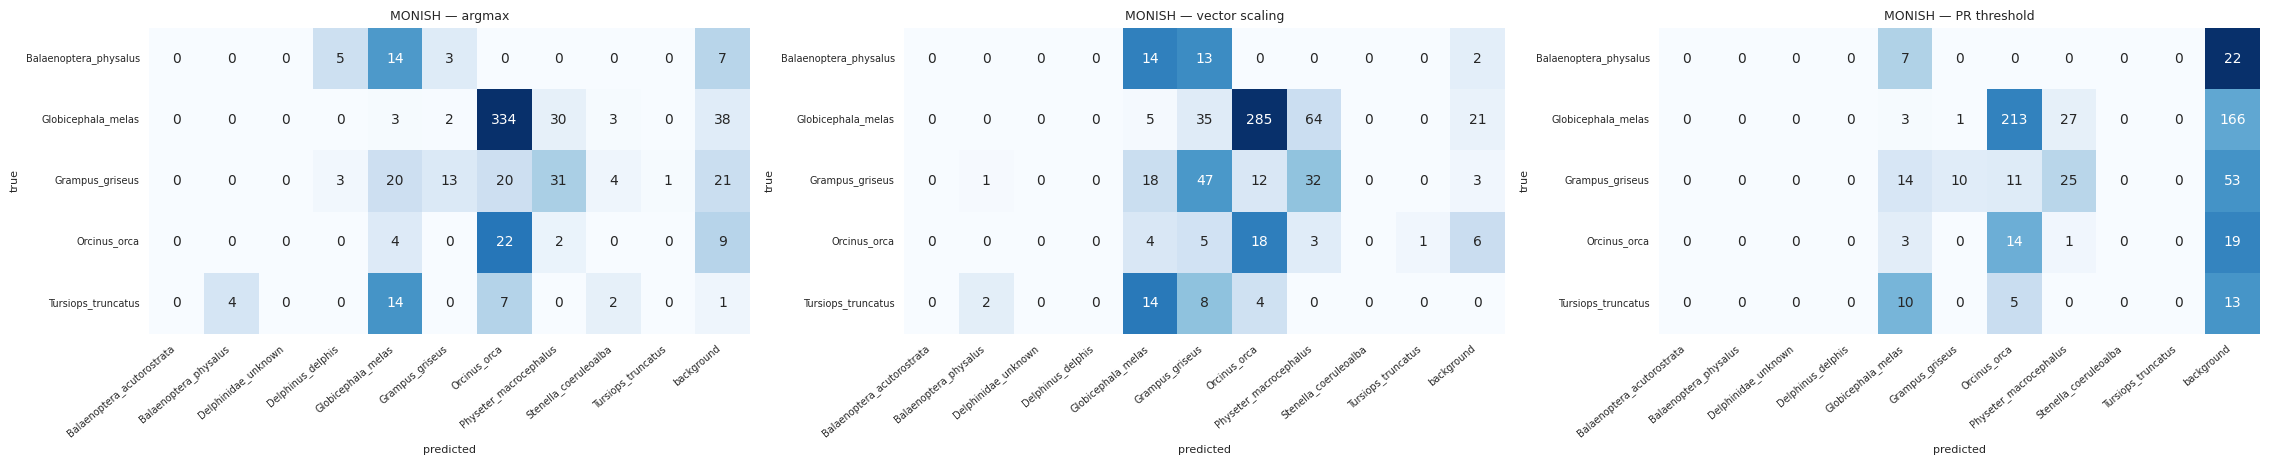


  OLTREMARE  |  T=1.334  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.779     0.779     0.765     0.823
  balanced accuracy                          0.805     0.805     0.805     0.785
  --- species rows only ---             
  species recall (macro)                     0.739     0.739     0.759     0.596
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.850     0.850     0.863     0.747
  inter-species confusion                    0.026     0.026     0.025     0.002
  hallucination rate                         0.026     0.026     0.025     0.002


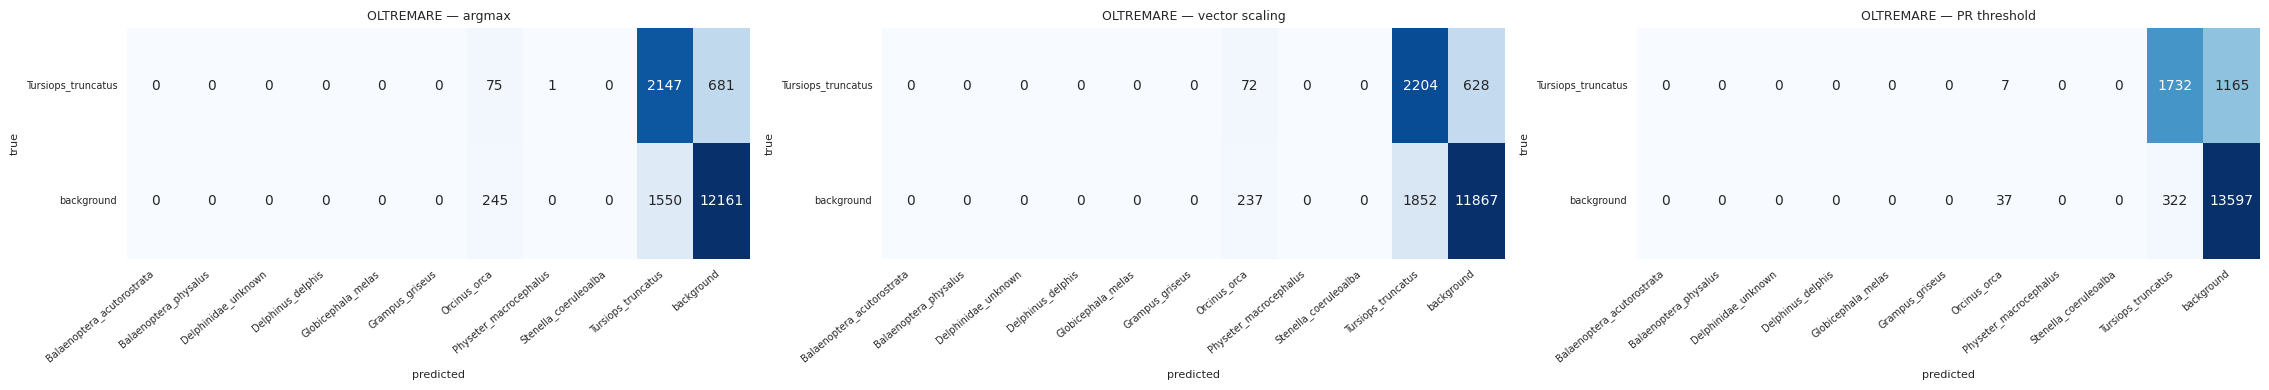


  WATKINS  |  T=1.951  |  classes: ['Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.144     0.144     0.192     0.145
  balanced accuracy                          0.324     0.324     0.340     0.176
  --- species rows only ---             
  species recall (macro)                     0.324     0.324     0.340     0.176
  species precision (macro)                  0.236     0.236     0.263     0.132
  species macro F1                           0.144     0.144     0.192     0.145
  inter-species confusion                    0.302     0.302     0.297     0.084
  hallucination rate                         0.004     0.004     0.008     0.005


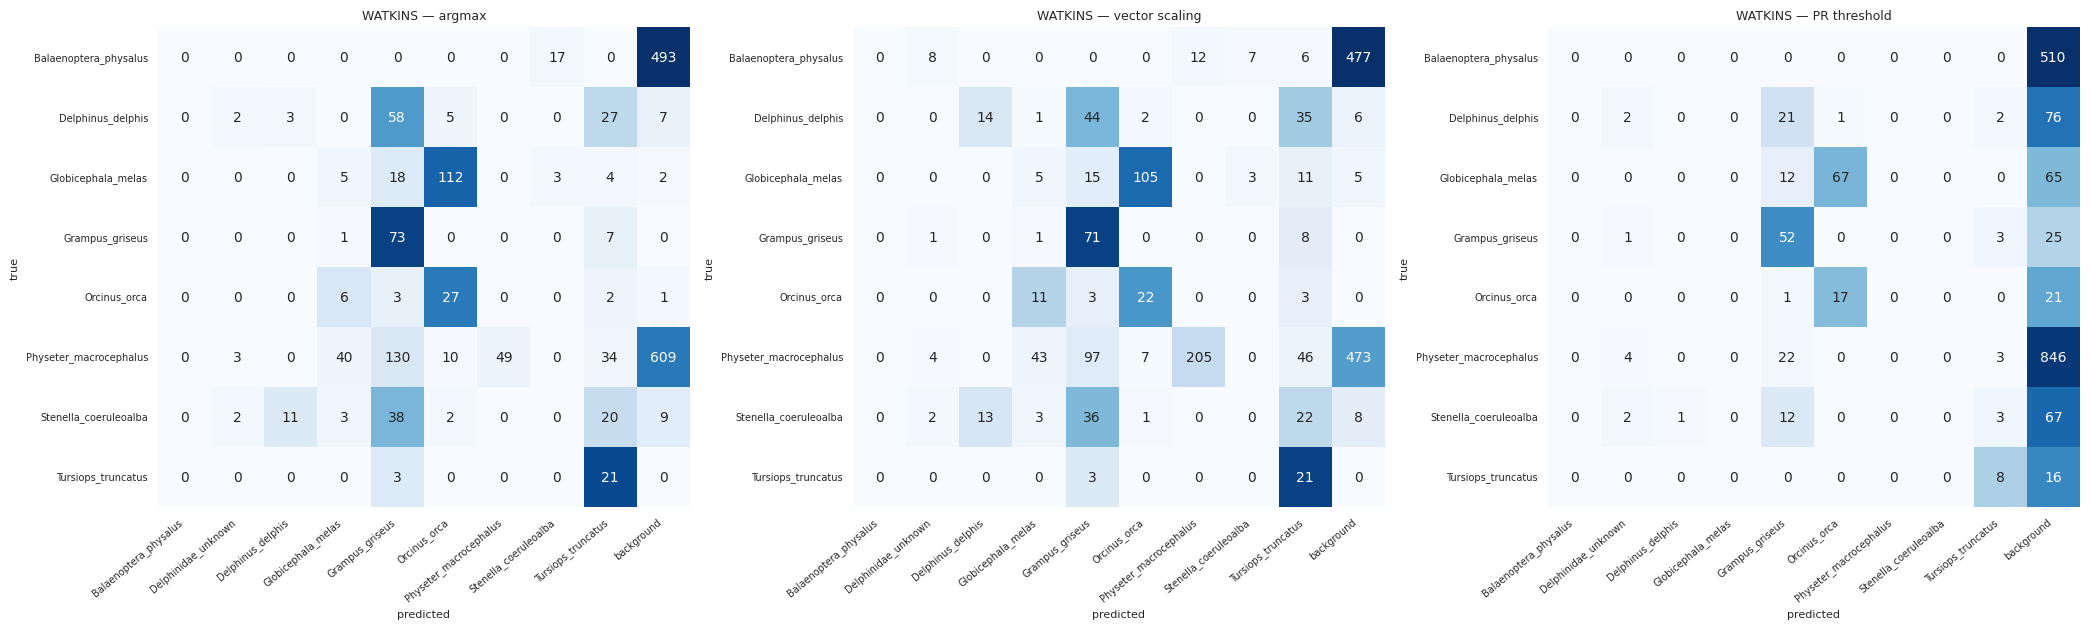

In [18]:
for ds, r in results_l4.items():
    report_fold(r, bg_label='background')

In [19]:
summary_l4 = make_summary_df(results_l4, 'L4-species')
print('\nLevel 4 — species-only metrics (all strategies):')
print(summary_l4[[
    'held_out','n_test','n_classes_test','sp_n_rows',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin',
    'temperature',
]].to_string(index=False))
summary_l4.to_csv(OUT_DIR / 'summary_l4.csv', index=False)



Level 4 — species-only metrics (all strategies):
          held_out  n_test  n_classes_test  sp_n_rows  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin  temperature
         OLTREMARE   16860               2       2904          0.739325       0.758953             0.596419        1.000000     1.000000           1.000000      0.850129   0.862960         0.747196         0.026171      0.024793            0.002410        1.334
      Adriatic_Sea    1180               2        942          0.764331       0.737792             0.447983        1.000000     1.000000           1.000000      0.866426   0.849114         0.618768         0.055202      0.139066            0.027601        1.434
    ECOSS_enhanced     168               6        143          0.565926       0.552593             0.530370        0.572381     0.580093           0.600000      0.5

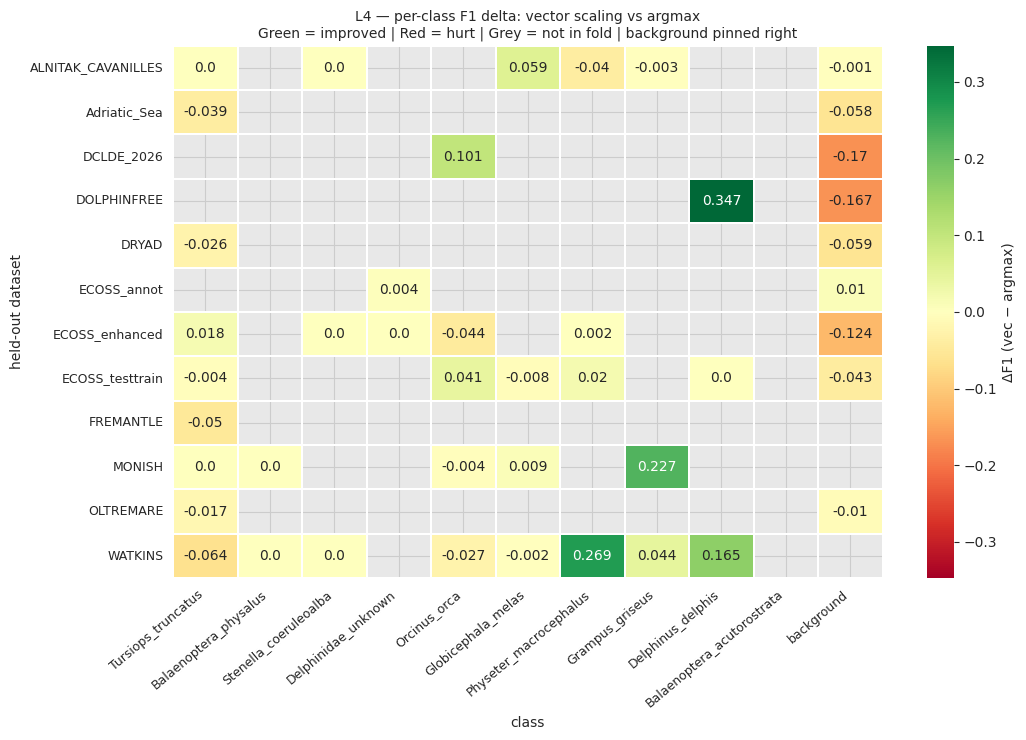


Mean ΔF1 per class (vec − argmax):
class
background                   -0.069
Tursiops_truncatus           -0.020
Stenella_coeruleoalba         0.000
Balaenoptera_physalus         0.000
Delphinidae_unknown           0.002
Orcinus_orca                  0.013
Globicephala_melas            0.015
Physeter_macrocephalus        0.063
Grampus_griseus               0.090
Delphinus_delphis             0.171
Balaenoptera_acutorostrata      NaN


In [20]:
_ = per_class_delta_heatmap(
    results_l4, 'vec', 'argmax',
    title='L4 — per-class F1 delta: vector scaling vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_vec_delta_heatmap.png',
    bg_label='background'
)

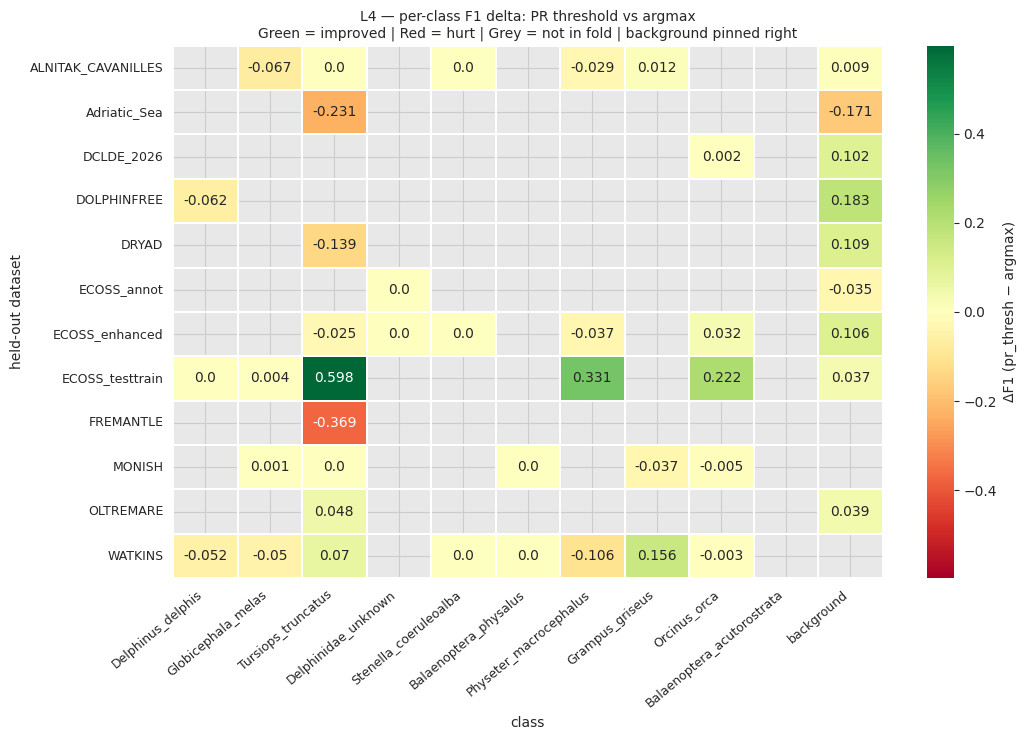


Mean ΔF1 per class (pr_thresh − argmax):
class
Delphinus_delphis            -0.038
Globicephala_melas           -0.028
Tursiops_truncatus           -0.005
Delphinidae_unknown           0.000
Stenella_coeruleoalba         0.000
Balaenoptera_physalus         0.000
Physeter_macrocephalus        0.040
background                    0.042
Grampus_griseus               0.044
Orcinus_orca                  0.050
Balaenoptera_acutorostrata      NaN


In [21]:
_ = per_class_delta_heatmap(
    results_l4, 'pr_thresh', 'argmax',
    title='L4 — per-class F1 delta: PR threshold vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_pr_thresh_delta_heatmap.png',
    bg_label='background'
)


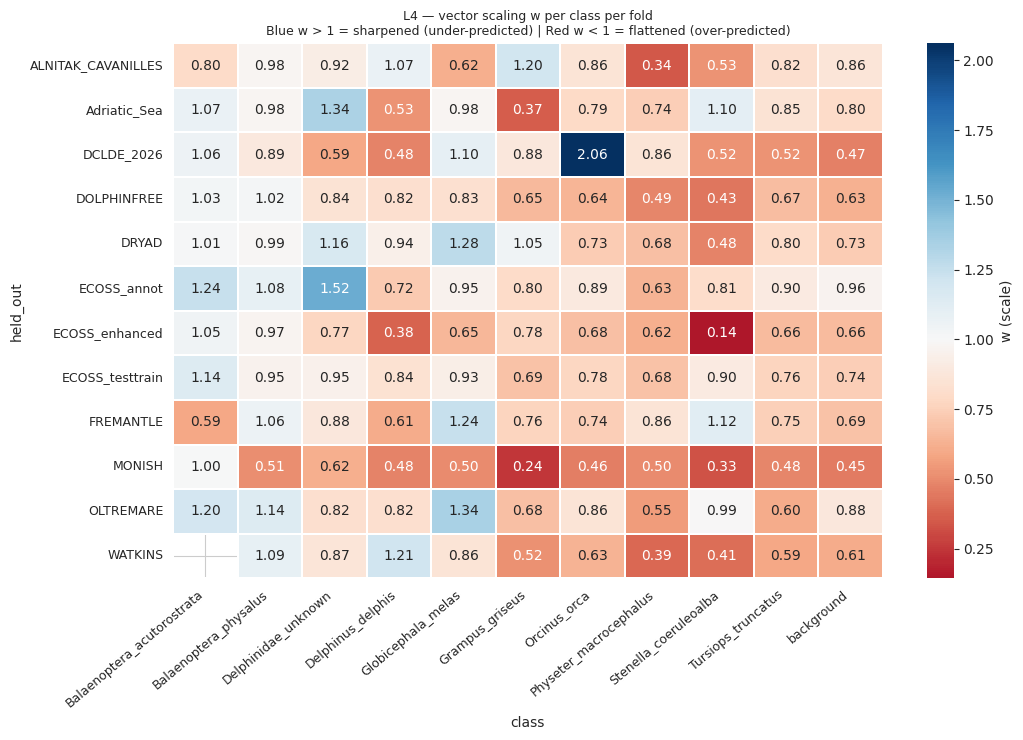

In [22]:
# ── Vector w heatmap ─────────────────────────────────────────────────────────
w_rows = []
for ds, r in results_l4.items():
    for c_name, w_val in zip(r['class_names'], r['vec_w']):
        w_rows.append({'held_out': ds, 'class': c_name, 'w': float(w_val)})

w_pivot = pd.DataFrame(w_rows).pivot(index='held_out', columns='class', values='w')
sp_cols = [c for c in w_pivot.columns if c != 'background']
w_pivot = w_pivot[sorted(sp_cols) + (['background'] if 'background' in w_pivot.columns else [])]

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(w_pivot.columns)+2),
                                 max(5, 0.5*len(w_pivot)+1.5)))
sns.heatmap(w_pivot, cmap='RdBu', center=1.0, annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'w (scale)'})
ax.set_title(
    'L4 — vector scaling w per class per fold\n'
    'Blue w > 1 = sharpened (under-predicted) | Red w < 1 = flattened (over-predicted)',
    fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_vec_w_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

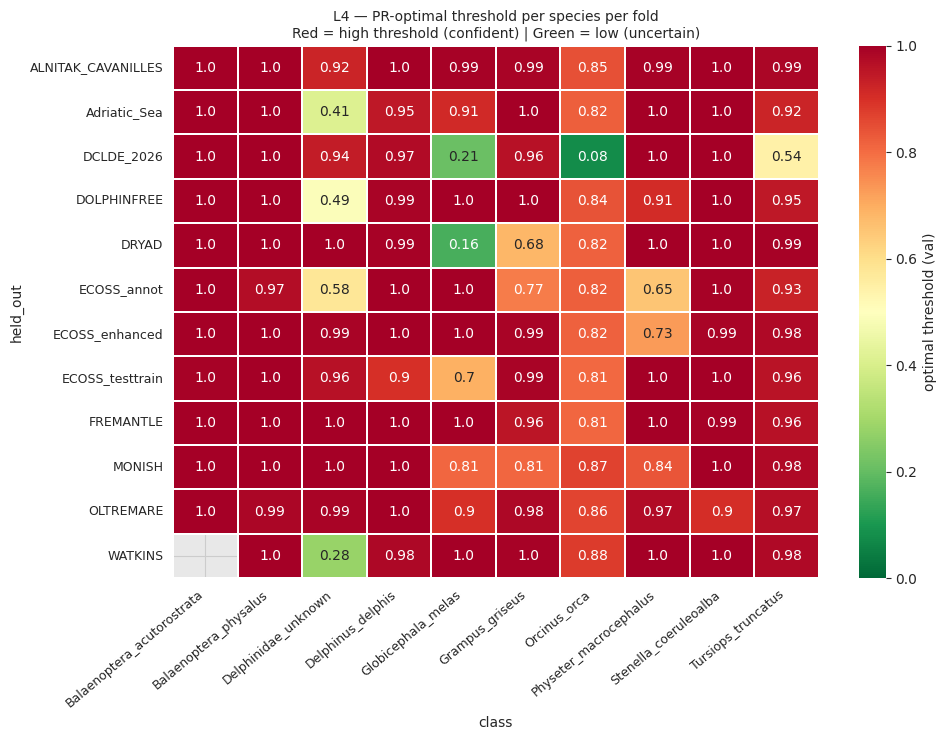

In [23]:
# ── PR threshold heatmap: what threshold was fit per species per fold ────────
thr_rows = []
for ds, r in results_l4.items():
    for cls_name, thr in r['pr_thresholds'].items():
        if cls_name == 'background': continue
        thr_rows.append({'held_out': ds, 'class': cls_name, 'threshold': thr})

thr_pivot = pd.DataFrame(thr_rows).pivot(index='held_out', columns='class', values='threshold')

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(thr_pivot.columns)+2),
                                 max(5,  0.5*len(thr_pivot)+1.5)))
sns.heatmap(thr_pivot, cmap='RdYlGn_r', vmin=0, vmax=1,
            annot=thr_pivot.round(2), fmt='', linewidths=0.3, ax=ax,
            mask=thr_pivot.isna(), cbar_kws={'label': 'optimal threshold (val)'})
ax.set_facecolor('#e8e8e8')
ax.set_title('L4 — PR-optimal threshold per species per fold\n'
             'Red = high threshold (confident) | Green = low (uncertain)',
             fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_pr_threshold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


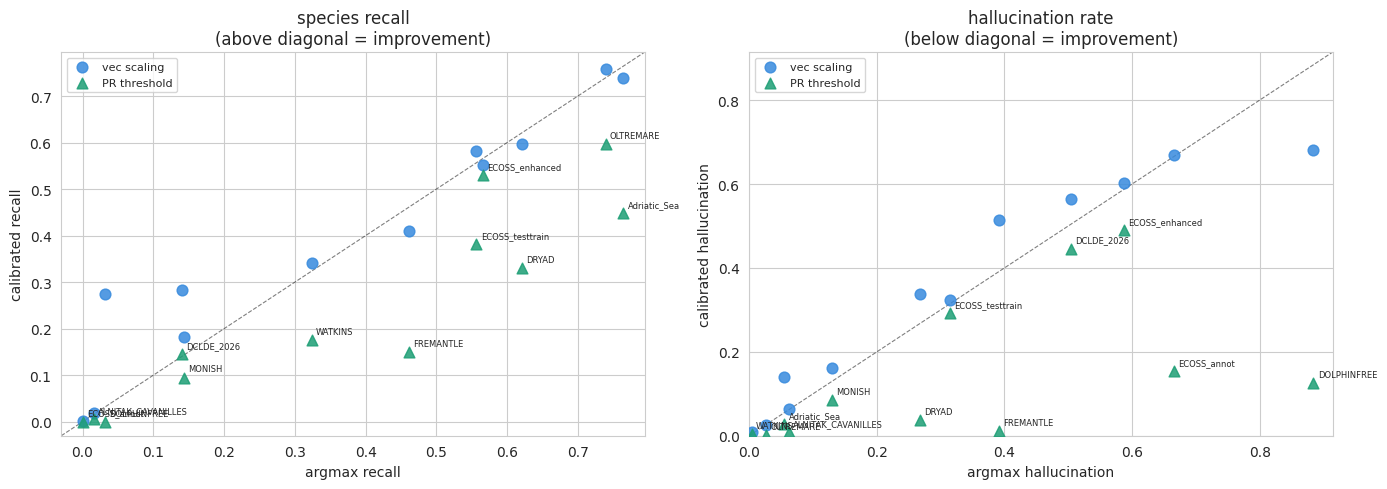

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sub = summary_l4.dropna(subset=['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall'])
lim = [min(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].min()) - 0.03,
       max(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].max()) + 0.03]
ax.scatter(sub['argmax_sp_recall'], sub['vec_sp_recall'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub['argmax_sp_recall'], sub['pr_thresh_sp_recall'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub.iterrows():
    ax.annotate(row['held_out'], (row['argmax_sp_recall'], row['pr_thresh_sp_recall']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('argmax recall'); ax.set_ylabel('calibrated recall')
ax.set_title('species recall\n(above diagonal = improvement)')
ax.legend(fontsize=8)

ax = axes[1]
sub2 = summary_l4.dropna(subset=['argmax_hallucin','vec_hallucin','pr_thresh_hallucin'])
lim2 = [0, max(sub2[['argmax_hallucin','vec_hallucin','pr_thresh_hallucin']].max()) + 0.03]
ax.scatter(sub2['argmax_hallucin'], sub2['vec_hallucin'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub2['argmax_hallucin'], sub2['pr_thresh_hallucin'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub2.iterrows():
    ax.annotate(row['held_out'], (row['argmax_hallucin'], row['pr_thresh_hallucin']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim2, lim2, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel('argmax hallucination'); ax.set_ylabel('calibrated hallucination')
ax.set_title('hallucination rate\n(below diagonal = improvement)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'recall_hallucin_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
all_summary = pd.concat([summary_l2, summary_l4], ignore_index=True)
all_summary.to_csv(OUT_DIR / 'summary_all_levels.csv', index=False)

print('Mean species metrics by level and strategy:')
rows_out = []
for level, df in [('L2', summary_l2), ('L4', summary_l4)]:
    for strat, rcol, pcol, fcol, hcol in [
        ('argmax',    'argmax_sp_recall',    'argmax_sp_prec',    'argmax_sp_f1',    'argmax_hallucin'),
        ('temp',      'temp_sp_recall',      'temp_sp_prec',      'temp_sp_f1',      None),
        ('vec',       'vec_sp_recall',       'vec_sp_prec',       'vec_sp_f1',       'vec_hallucin'),
        ('pr_thresh', 'pr_thresh_sp_recall', 'pr_thresh_sp_prec', 'pr_thresh_sp_f1', 'pr_thresh_hallucin'),
    ]:
        sub = df.dropna(subset=[rcol, pcol, fcol])
        if sub.empty: continue
        row = {'level': level, 'strategy': strat,
               'mean_recall':    round(sub[rcol].mean(), 4),
               'mean_precision': round(sub[pcol].mean(), 4),
               'mean_sp_f1':     round(sub[fcol].mean(), 4)}
        if hcol:
            row['mean_hallucin'] = round(sub[hcol].dropna().mean(), 4)
        rows_out.append(row)
print(pd.DataFrame(rows_out).to_string(index=False))


Mean species metrics by level and strategy:
level  strategy  mean_recall  mean_precision  mean_sp_f1  mean_hallucin
   L2    argmax       0.5613          0.8123      0.5876         0.0373
   L2      temp       0.5613          0.8123      0.5876            NaN
   L2       vec       0.5756          0.8108      0.5981         0.0408
   L2 pr_thresh       0.5048          0.8259      0.5491         0.0317
   L4    argmax       0.3637          0.6693      0.3951         0.3243
   L4      temp       0.3637          0.6693      0.3951            NaN
   L4       vec       0.3949          0.7358      0.4474         0.3407
   L4 pr_thresh       0.2383          0.5793      0.2997         0.1404


## 10. Persist artefacts

In [26]:
def save_preds(name, r):
    rows_te     = r.get('rows_te')
    class_names = r.get('class_names')
    if rows_te is None or class_names is None: return
    df = meta_all.iloc[rows_te][[
        'dataset','region','environment','group_key',
        'label_t1','label_t2','label_t3','label_t4'
    ]].copy()
    df['y_true']      = [class_names[i] for i in r['yte']]
    df['y_argmax']    = [class_names[i] for i in r['y_argmax']]
    df['y_temp']      = [class_names[i] for i in r['y_temp']]
    df['y_vec']       = [class_names[i] for i in r['y_vec']]
    df['y_pr_thresh'] = [class_names[i] for i in r['y_pr_thresh']]
    for ci, cn in enumerate(class_names):
        df[f'prob_raw_{cn}'] = r['proba_raw'][:, ci]
        df[f'prob_vec_{cn}'] = r['proba_vec'][:, ci]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)
    print(f"  {fp.name}  ({len(df):,} rows)")

print('Level 2:'); [save_preds(f'l2_{ds}', r) for ds, r in results_l2.items()]
print('Level 4:'); [save_preds(f'l4_{ds}', r) for ds, r in results_l4.items()]

# save per-fold PR thresholds as JSON
all_thresholds = {ds: r['pr_thresholds'] for ds, r in results_l4.items()}
with open(OUT_DIR / 'l4_pr_thresholds_per_fold.json', 'w') as f:
    json.dump(all_thresholds, f, indent=2)
print(f'\nPR thresholds  → {OUT_DIR}/l4_pr_thresholds_per_fold.json')
print(f'All artefacts  → {OUT_DIR.resolve()}')


Level 2:
  preds_l2_ALNITAK_CAVANILLES.parquet  (5,202 rows)
  preds_l2_Adriatic_Sea.parquet  (1,180 rows)
  preds_l2_DCLDE_2026.parquet  (174,538 rows)
  preds_l2_DOLPHINFREE.parquet  (3,290 rows)
  preds_l2_DRYAD.parquet  (6,770 rows)
  preds_l2_ECOSS_annot.parquet  (752 rows)
  preds_l2_ECOSS_enhanced.parquet  (168 rows)
  preds_l2_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l2_FREMANTLE.parquet  (332 rows)
  preds_l2_MONISH.parquet  (617 rows)
  preds_l2_OLTREMARE.parquet  (16,860 rows)
  preds_l2_WATKINS.parquet  (1,877 rows)
Level 4:
  preds_l4_ALNITAK_CAVANILLES.parquet  (4,786 rows)
  preds_l4_Adriatic_Sea.parquet  (1,180 rows)
  preds_l4_DCLDE_2026.parquet  (174,538 rows)
  preds_l4_DOLPHINFREE.parquet  (3,290 rows)
  preds_l4_DRYAD.parquet  (6,770 rows)
  preds_l4_ECOSS_annot.parquet  (752 rows)
  preds_l4_ECOSS_enhanced.parquet  (168 rows)
  preds_l4_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l4_FREMANTLE.parquet  (332 rows)
  preds_l4_MONISH.parquet  (617 rows)
  pre